In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data.head()

,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D29,D30,D31,D32,D33,D34,D35,D36,D37,D38
0,ACSM1,10.914760,11.135962,8.891566,8.074361,9.557551,10.132283,10.019072,8.925043,11.817970,...,7.659350,6.397556,6.226404,5.630004,7.850567,6.779979,5.882256,10.540738,7.262209,7.532407
1,ADORA2B,5.110096,5.805840,4.750283,5.620902,5.434974,5.514895,4.450006,6.229374,4.439311,...,6.540154,5.116456,5.080135,7.398721,6.450155,3.579958,5.938070,6.692122,6.385460,5.950856
2,AGPAT1,3.896571,5.078981,4.389263,5.705530,5.356997,5.326282,5.437688,4.551041,2.857657,...,5.213546,5.277771,6.954467,7.280251,6.796259,8.176044,6.867025,6.206010,7.782533,6.400674
3,BTBD16,6.838794,6.487988,6.991046,5.690952,6.632153,6.535228,6.927929,4.979223,7.734810,...,4.949167,4.854093,2.889749,5.578432,5.914876,6.037106,4.780228,3.544489,3.142159,4.833111
4,CCDC178,6.137514,6.115845,5.544265,6.502288,8.371001,6.477630,8.866079,5.789687,5.656918,...,4.466889,4.313042,3.611286,4.570975,5.151161,3.790559,4.200692,4.406053,4.664216,4.987756


In [3]:
data = data.T

In [4]:
y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y
data.reset_index(inplace = True)

data.drop("index", axis = 1, inplace = True)
X = data
# Make first row the header
X.columns = X.iloc[0]

# Remove that first row
X = X.drop(X.index[0])

# Convert to numeric
#X = X.apply(pd.to_numeric)
X


,ACSM1,ADORA2B,AGPAT1,BTBD16,CCDC178,CD207,CLRN1,CMA1,CSMD1,DDT,...,SFRP4,SIK1,SLC2A14,SORCS3,STC1,TBC1D3L,TNFRSF17,TYR,USP17L2,WDR46
1,10.91476,5.110096,3.896571,6.838794,6.137514,6.335811,6.009826,4.404689,8.698855,3.646425,...,12.193521,5.697186,2.97466,5.043856,6.742106,4.391362,5.723762,7.119836,8.620417,4.919325
2,11.135962,5.80584,5.078981,6.487988,6.115845,4.977656,5.474359,5.22186,7.239703,3.538015,...,10.48046,5.022233,4.24729,4.857951,4.822149,4.3735,6.082677,6.200747,8.470901,4.8774
3,8.891566,4.750283,4.389263,6.991046,5.544265,5.854893,6.827014,5.897843,10.042353,4.492789,...,11.926017,4.8805,3.793164,3.88119,7.631016,4.57199,5.470134,5.550446,8.192874,3.748831
4,8.074361,5.620902,5.70553,5.690952,6.502288,5.733583,4.6523,5.626731,8.580342,3.771152,...,13.494115,6.238118,2.781264,5.574711,8.175455,4.230194,6.473276,5.648787,7.811523,3.628753
5,9.557551,5.434974,5.356997,6.632153,8.371001,6.031605,5.919477,4.324369,7.79012,3.969257,...,11.788102,6.211392,3.135282,3.558551,6.543452,4.989646,6.105548,6.003599,7.399032,4.015435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,6.779979,3.579958,8.176044,6.037106,3.790559,5.955599,8.112708,3.799325,6.478235,3.457107,...,10.890283,6.371103,5.944549,7.714985,9.056544,2.989828,5.051926,4.590912,7.227312,7.534752
68,5.882256,5.93807,6.867025,4.780228,4.200692,7.120193,7.008641,5.27548,6.822246,3.674302,...,11.551356,4.638456,5.725493,7.030303,9.135109,4.42579,4.72124,4.575075,6.103253,6.043637
69,10.540738,6.692122,6.20601,3.544489,4.406053,8.428116,6.119198,3.879046,8.752773,3.514716,...,9.344778,6.806512,4.146754,4.050462,10.532865,5.542763,4.414228,4.553074,5.016077,5.212523
70,7.262209,6.38546,7.782533,3.142159,4.664216,6.850532,4.242906,4.150065,6.151992,5.022798,...,10.195798,9.094513,3.853907,4.198532,11.917931,5.721694,5.591699,2.992995,2.595225,4.808556


In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import make_scorer, matthews_corrcoef
import pandas as pd

# ── Inner CV for GridSearch ────────────────────────────────────────────────
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Outer CV for Final Evaluation ─────────────────────────────────────────
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ── Hyperparameter Grid ────────────────────────────────────────────────────
param_grid = [
    {
        "C"      : [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver" : ["liblinear", "lbfgs", "saga"]
    },
    {
        "C"      : [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
        "penalty": ["l1"],
        "solver" : ["liblinear", "saga"]          # l1 only supports these
    }
]

# ── Base Estimator ─────────────────────────────────────────────────────────
base_model = LogisticRegression(max_iter=1000, random_state=42)

# ── GridSearchCV (inner loop) ──────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator  = base_model,
    param_grid = param_grid,
    cv         = inner_cv,
    scoring    = "roc_auc",          # optimise for AUC in inner loop
    n_jobs     = -1,
    refit      = True,
    verbose    = 1
)

# ── Fit to find best hyperparameters ──────────────────────────────────────
grid_search.fit(X, y)

print("Best Parameters :", grid_search.best_params_)
print(f"Best Inner AUC  : {grid_search.best_score_:.4f}")

# ── Rebuild best model for outer CV ───────────────────────────────────────
best_model = LogisticRegression(
    max_iter     = 1000,
    random_state = 42,
    **grid_search.best_params_
)

# ── Evaluation Metrics ─────────────────────────────────────────────────────
scoring = {
    "accuracy"  : "accuracy",
    "precision" : "precision",
    "recall"    : "recall",
    "f1"        : "f1",
    "roc_auc"   : "roc_auc",
    "mcc"       : make_scorer(matthews_corrcoef),
}

# ── Outer Cross-Validation ─────────────────────────────────────────────────
results = cross_validate(
    best_model,
    X, y,
    cv                = outer_cv,
    scoring           = scoring,
    return_train_score= True,
    n_jobs            = -1
)

# ── GridSearch CV Results Summary ─────────────────────────────────────────
cv_results_df = pd.DataFrame(grid_search.cv_results_)[
    ["param_C", "param_penalty", "param_solver",
     "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score").head(10)

print("\nTop 10 Hyperparameter Combinations (by inner CV AUC):")
print(cv_results_df.to_string(index=False))

# ── Publication-Style Results Table ───────────────────────────────────────
metrics_map = {
    "accuracy" : "Accuracy",
    "precision": "Precision",
    "recall"   : "Recall",
    "f1"       : "F1-Score",
    "roc_auc"  : "ROC-AUC",
    "mcc"      : "MCC",
}

rows = []
for key, label in metrics_map.items():
    test_vals  = results[f"test_{key}"]
    train_vals = results[f"train_{key}"]
    rows.append({
        "Metric"         : label,
        "Train Mean ± SD": f"{train_vals.mean():.4f} ± {train_vals.std():.4f}",
        "Test Mean ± SD" : f"{test_vals.mean():.4f} ± {test_vals.std():.4f}",
        "95% CI"         : f"[{np.percentile(test_vals, 2.5):.4f}, "
                           f"{np.percentile(test_vals, 97.5):.4f}]",
        "Min / Max"      : f"{test_vals.min():.4f} / {test_vals.max():.4f}"
    })

df = pd.DataFrame(rows).set_index("Metric")
print("\nFinal Model Performance (Outer 10-Fold CV):")
print(df.to_string())

           Train Mean ± SD   Test Mean ± SD            95% CI        Min / Max
Metric                                                                        
Accuracy   0.9781 ± 0.0438  0.9589 ± 0.0897  [0.7504, 1.0000]  0.7143 / 1.0000
Precision  0.9667 ± 0.0667  0.9400 ± 0.1281  [0.6450, 1.0000]  0.6000 / 1.0000
Recall     1.0000 ± 0.0000  1.0000 ± 0.0000  [1.0000, 1.0000]  1.0000 / 1.0000
F1-Score   0.9818 ± 0.0364  0.9639 ± 0.0786  [0.7812, 1.0000]  0.7500 / 1.0000
ROC-AUC    1.0000 ± 0.0000  1.0000 ± 0.0000  [1.0000, 1.0000]  1.0000 / 1.0000
MCC        0.9590 ± 0.0820  0.9322 ± 0.1447  [0.5988, 1.0000]  0.5477 / 1.0000


In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef
import pandas as pd

# ── Logistic Regression Model ──────────────────────────────────────────────
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=0.0001,
    penalty='l2',
    solver='liblinear'
)

# ── Stratified K-Fold CV ───────────────────────────────────────────────────
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# ── Evaluation Metrics ─────────────────────────────────────────────────────
scoring = {
    "accuracy"  : "accuracy",
    "precision" : "precision",
    "recall"    : "recall",
    "f1"        : "f1",
    "roc_auc"   : "roc_auc",
    "mcc"       : make_scorer(matthews_corrcoef),
}

# ── Cross Validation ───────────────────────────────────────────────────────
results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# ── Publication-Style Results Table ────────────────────────────────────────
metrics_map = {
    "accuracy" : "Accuracy",
    "precision": "Precision",
    "recall"   : "Recall",
    "f1"       : "F1-Score",
    "roc_auc"  : "ROC-AUC",
    "mcc"      : "MCC",
}

rows = []

for key, label in metrics_map.items():

    test_vals = results[f"test_{key}"]
    train_vals = results[f"train_{key}"]

    rows.append({
        "Metric": label,
        "Train Mean ± SD":
            f"{train_vals.mean():.4f} ± {train_vals.std():.4f}",

        "Test Mean ± SD":
            f"{test_vals.mean():.4f} ± {test_vals.std():.4f}",

        "95% CI":
            f"[{np.percentile(test_vals, 2.5):.4f}, "
            f"{np.percentile(test_vals, 97.5):.4f}]",

        "Min / Max":
            f"{test_vals.min():.4f} / {test_vals.max():.4f}"
    })

df = pd.DataFrame(rows).set_index("Metric")

print(df.to_string())

{'C': 0.1}
1.0


In [7]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_validate
)
from sklearn.metrics import make_scorer, matthews_corrcoef

# ── Logistic Regression Model ──────────────────────────────────────────────
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=0.0001,
    penalty='l2',
    solver='liblinear'
)

# ── Repeated Stratified K-Fold ─────────────────────────────────────────────
cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=10,
    random_state=42
)

# ── Evaluation Metrics ─────────────────────────────────────────────────────
scoring = {
    "accuracy"  : "accuracy",
    "precision" : "precision",
    "recall"    : "recall",
    "f1"        : "f1",
    "roc_auc"   : "roc_auc",
    "mcc"       : make_scorer(matthews_corrcoef),
}

# ── Cross Validation ───────────────────────────────────────────────────────
results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# ── Publication-Style Results Table ────────────────────────────────────────
metrics_map = {
    "accuracy" : "Accuracy",
    "precision": "Precision",
    "recall"   : "Recall",
    "f1"       : "F1-Score",
    "roc_auc"  : "ROC-AUC",
    "mcc"      : "MCC",
}

rows = []

for key, label in metrics_map.items():

    test_vals = results[f"test_{key}"]
    train_vals = results[f"train_{key}"]

    rows.append({
        "Metric": label,

        "Train Mean ± SD":
            f"{train_vals.mean():.4f} ± {train_vals.std():.4f}",

        "Test Mean ± SD":
            f"{test_vals.mean():.4f} ± {test_vals.std():.4f}",

        "95% CI":
            f"[{np.percentile(test_vals, 2.5):.4f}, "
            f"{np.percentile(test_vals, 97.5):.4f}]",

        "Min / Max":
            f"{test_vals.min():.4f} / {test_vals.max():.4f}"
    })

df = pd.DataFrame(rows).set_index("Metric")

print(df.to_string())

           Train Mean ± SD   Test Mean ± SD            95% CI        Min / Max
Metric                                                                        
Accuracy   0.9781 ± 0.0410  0.9516 ± 0.1163  [0.5714, 1.0000]  0.4286 / 1.0000
Precision  0.9660 ± 0.0626  0.9343 ± 0.1476  [0.5000, 1.0000]  0.4286 / 1.0000
Recall     1.0000 ± 0.0000  1.0000 ± 0.0000  [1.0000, 1.0000]  1.0000 / 1.0000
F1-Score   0.9816 ± 0.0341  0.9588 ± 0.0947  [0.6667, 1.0000]  0.6000 / 1.0000
ROC-AUC    1.0000 ± 0.0000  1.0000 ± 0.0000  [1.0000, 1.0000]  1.0000 / 1.0000
MCC        0.9587 ± 0.0768  0.9217 ± 0.1870  [0.3536, 1.0000]  0.0000 / 1.0000


In [9]:
import numpy as np
import pandas as pd
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_validate
)
from sklearn.metrics import make_scorer, matthews_corrcoef

# ── Repeated Stratified K-Fold ─────────────────────────────────────────────
cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=10,
    random_state=42
)

# ── Metrics ────────────────────────────────────────────────────────────────
scoring = {
    "accuracy"  : "accuracy",
    "precision" : "precision",
    "recall"    : "recall",
    "f1"        : "f1",
    "roc_auc"   : "roc_auc",
    "mcc"       : make_scorer(matthews_corrcoef),
}

# ── C values to test ───────────────────────────────────────────────────────
c_values = [0.0001, 0.001, 0.01, 0.1, 1, 5, 10]

# ── Store results ──────────────────────────────────────────────────────────
all_results = []

# ── Loop through C values ──────────────────────────────────────────────────
for c in c_values:

    model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=c,
        penalty='l2',
        solver='liblinear'
    )

    results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    row = {"C": c}

    for metric in scoring.keys():
        train_vals = results[f"train_{metric}"]
        test_vals  = results[f"test_{metric}"]

        row[f"{metric}_train_mean"] = train_vals.mean()
        row[f"{metric}_train_sd"]   = train_vals.std()
        row[f"{metric}_test_mean"]  = test_vals.mean()
        row[f"{metric}_test_sd"]    = test_vals.std()

    all_results.append(row)

# ── Convert to DataFrame ───────────────────────────────────────────────────
results_df = pd.DataFrame(all_results)

# ── Save CSV ───────────────────────────────────────────────────────────────
results_df.to_csv("logreg_c_tuning_results.csv", index=False)
print(results_df)
print("\nSaved as: logreg_c_tuning_results.csv")

# ── Select best C by test accuracy ────────────────────────────────────────
best_row     = results_df.loc[results_df["accuracy_test_mean"].idxmax()]
best_c       = best_row["C"]
best_acc     = best_row["accuracy_test_mean"]
best_acc_sd  = best_row["accuracy_test_sd"]

print(f"\nBest C            : {best_c}")
print(f"CV Test Accuracy  : {best_acc:.4f} ± {best_acc_sd:.4f}")

# ── Refit best model on full dataset ──────────────────────────────────────
best_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=best_c,
    penalty='l2',
    solver='liblinear'
)
best_model.fit(X, y)

# ── Save best model as .pkl ────────────────────────────────────────────────
pkl_path = f"logreg_best_C{best_c}.pkl"
joblib.dump(best_model, pkl_path)
print(f"Best model saved  : {pkl_path}")

# ── Quick sanity check: training accuracy of saved model ──────────────────
loaded_model   = joblib.load(pkl_path)
train_accuracy = loaded_model.score(X, y)
print(f"Full-data Train Accuracy (sanity check): {train_accuracy:.4f}")

        C  accuracy_train_mean  accuracy_train_sd  accuracy_test_mean  \
0  0.0001               0.9781             0.0410              0.9516   
1  0.0010               1.0000             0.0000              1.0000   
2  0.0100               1.0000             0.0000              1.0000   
3  0.1000               1.0000             0.0000              1.0000   
4  1.0000               1.0000             0.0000              1.0000   
5  5.0000               1.0000             0.0000              1.0000   
6 10.0000               1.0000             0.0000              1.0000   

   accuracy_test_sd  precision_train_mean  precision_train_sd  \
0            0.1163                0.9660              0.0626   
1            0.0000                1.0000              0.0000   
2            0.0000                1.0000              0.0000   
3            0.0000                1.0000              0.0000   
4            0.0000                1.0000              0.0000   
5            0.0000      

In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_validate
)
from sklearn.metrics import make_scorer, matthews_corrcoef

# ── Repeated Stratified K-Fold ─────────────────────────────────────────────
cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=10,
    random_state=42
)

# ── Metrics ────────────────────────────────────────────────────────────────
scoring = {
    "accuracy"  : "accuracy",
    "precision" : "precision",
    "recall"    : "recall",
    "f1"        : "f1",
    "roc_auc"   : "roc_auc",
    "mcc"       : make_scorer(matthews_corrcoef),
}

# ── Iteration values to test ───────────────────────────────────────────────
iteration_values = [100, 200, 300, 400, 500,
                    600, 700, 800, 900, 1000]

# ── Store results ──────────────────────────────────────────────────────────
all_results = []

# ── Loop through iteration values ──────────────────────────────────────────
for iters in iteration_values:

    model = LogisticRegression(
        max_iter=iters,
        random_state=42,
        C=0.0001,
        penalty='l2',
        solver='liblinear'
    )

    results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    row = {
        "max_iter": iters
    }

    # Add metric summaries
    for metric in scoring.keys():

        train_vals = results[f"train_{metric}"]
        test_vals  = results[f"test_{metric}"]

        row[f"{metric}_train_mean"] = train_vals.mean()
        row[f"{metric}_train_sd"]   = train_vals.std()

        row[f"{metric}_test_mean"]  = test_vals.mean()
        row[f"{metric}_test_sd"]    = test_vals.std()

    all_results.append(row)

# ── Convert to DataFrame ───────────────────────────────────────────────────
results_df = pd.DataFrame(all_results)

# ── Save CSV ───────────────────────────────────────────────────────────────
results_df.to_csv("logreg_iteration_tuning_results.csv", index=False)

# ── Display ────────────────────────────────────────────────────────────────
print(results_df)

print("\nSaved as: logreg_iteration_tuning_results.csv")

   max_iter  accuracy_train_mean  accuracy_train_sd  accuracy_test_mean  \
0       100               0.9781           0.040982            0.951607   
1       200               0.9781           0.040982            0.951607   
2       300               0.9781           0.040982            0.951607   
3       400               0.9781           0.040982            0.951607   
4       500               0.9781           0.040982            0.951607   
5       600               0.9781           0.040982            0.951607   
6       700               0.9781           0.040982            0.951607   
7       800               0.9781           0.040982            0.951607   
8       900               0.9781           0.040982            0.951607   
9      1000               0.9781           0.040982            0.951607   

   accuracy_test_sd  precision_train_mean  precision_train_sd  \
0          0.116313              0.965966            0.062574   
1          0.116313              0.965966   

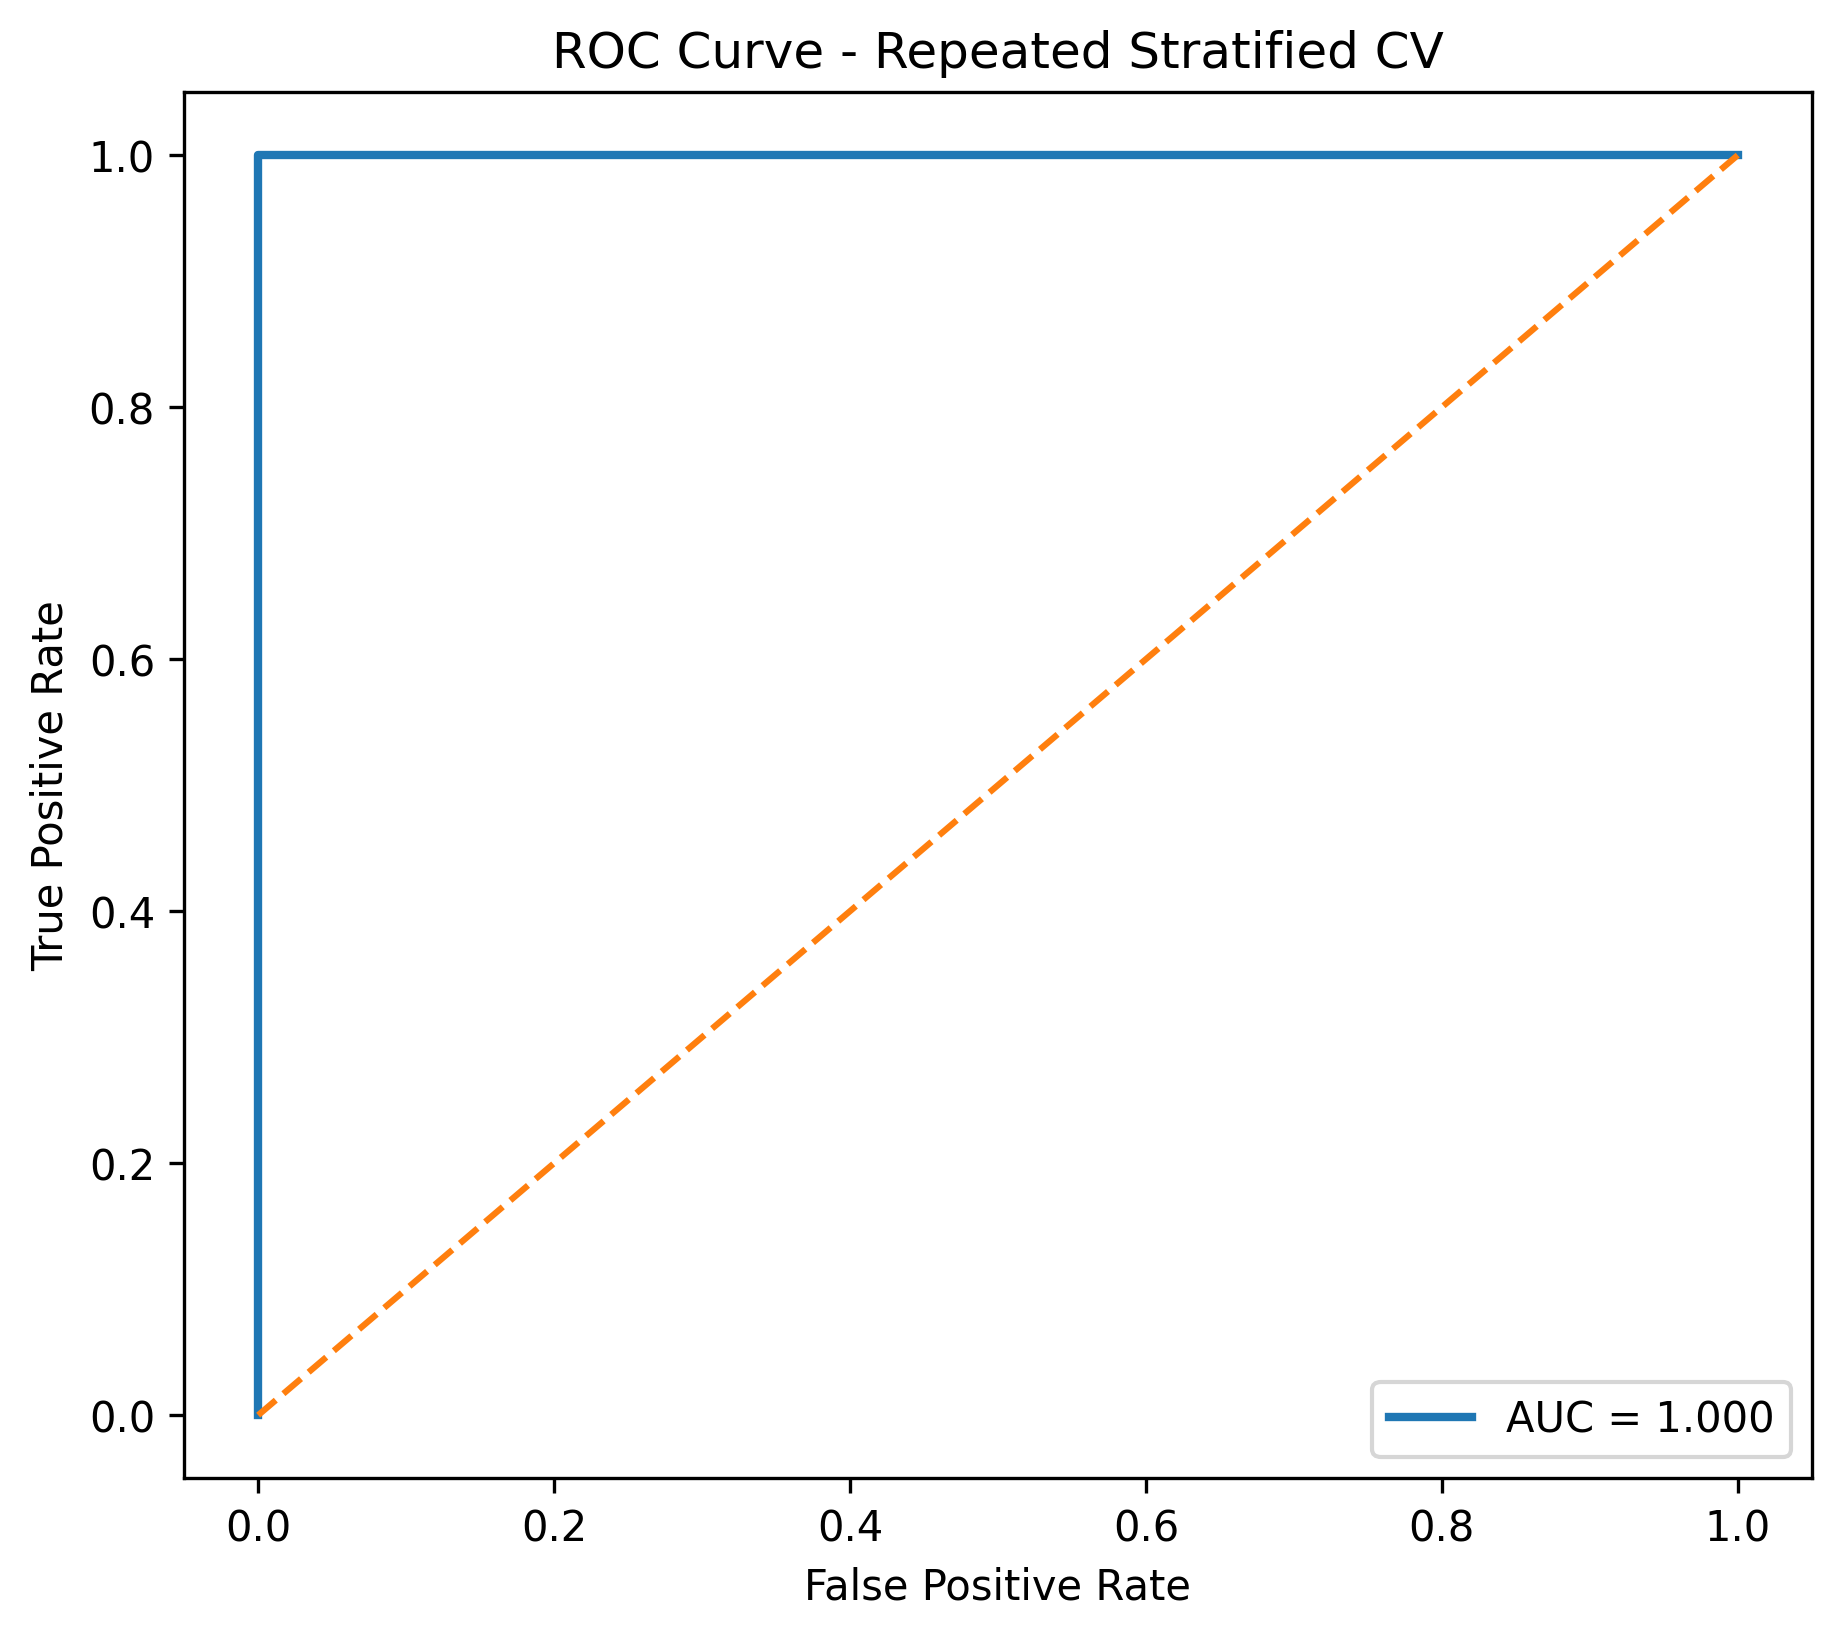

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ── Store probabilities manually ──────────────────────────────────
y_true_all = []
y_prob_all = []

# ── Repeated CV loop ──────────────────────────────────────────────
for train_idx, test_idx in cv.split(X, y):

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=0.0001,
        penalty='l2',
        solver='liblinear'
    )

    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:, 1]

    y_true_all.extend(y_test)
    y_prob_all.extend(probs)

# ── Convert to arrays ─────────────────────────────────────────────
y_true_all = np.array(y_true_all)
y_prob_all = np.array(y_prob_all)

# ── ROC calculation ───────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_true_all, y_prob_all)
roc_auc = auc(fpr, tpr)

# ── Plot ──────────────────────────────────────────────────────────
plt.figure(figsize=(7,6), dpi=300)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Repeated Stratified CV")
plt.legend(loc="lower right")

plt.show()

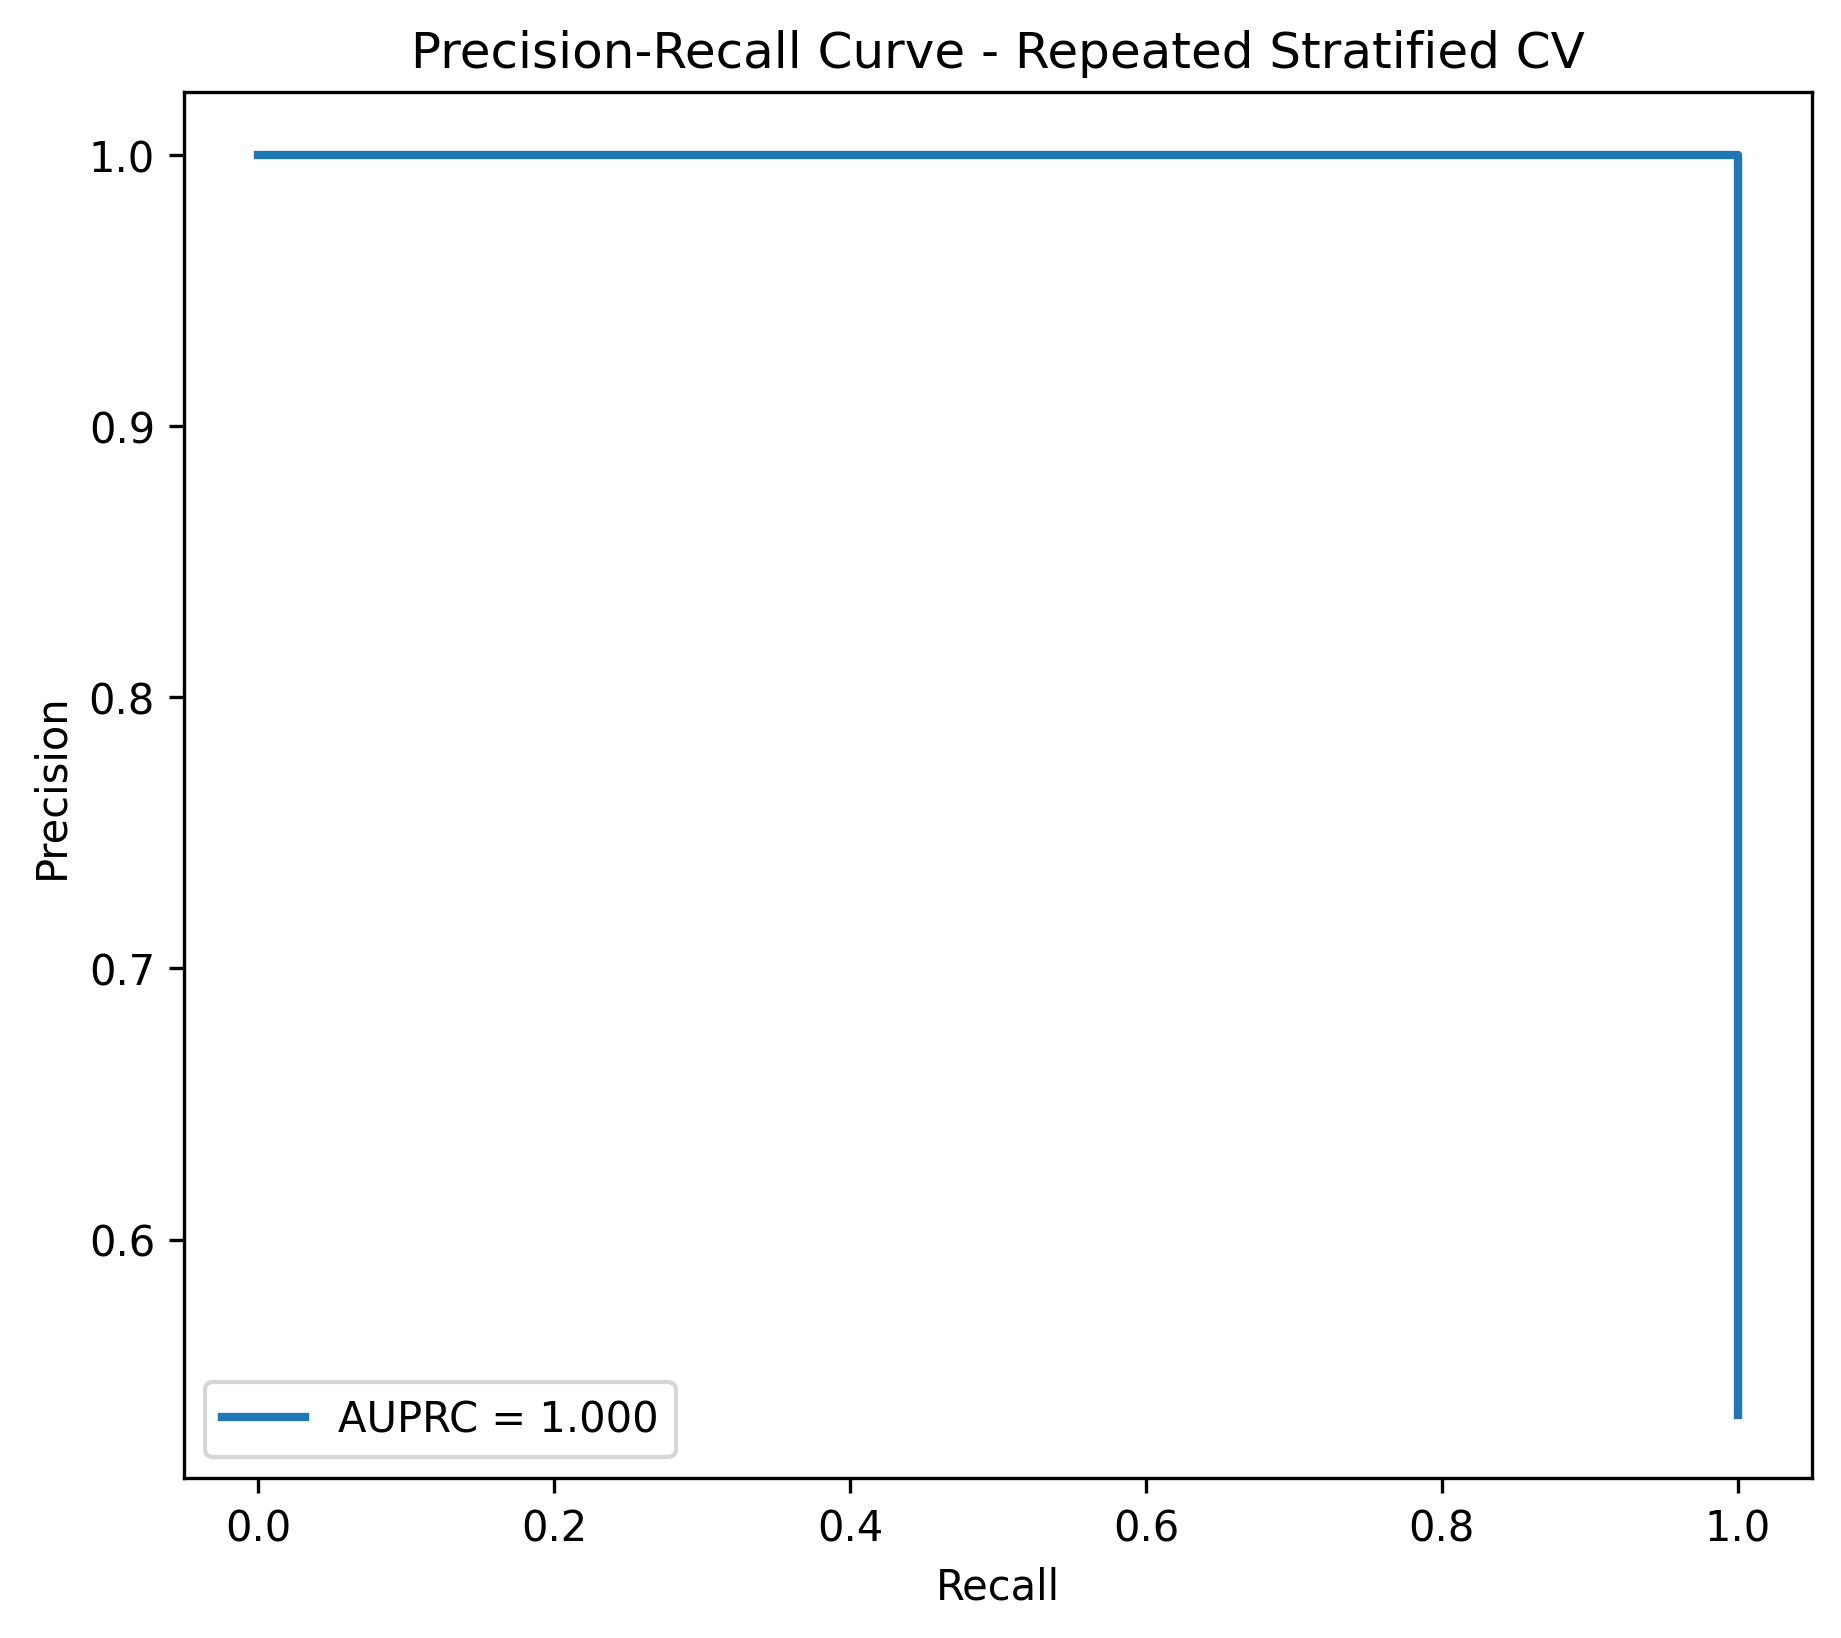

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# ── Precision-Recall Curve ────────────────────────────────────────
precision, recall, thresholds = precision_recall_curve(
    y_true_all,
    y_prob_all
)

auc_pr = average_precision_score(y_true_all, y_prob_all)

# ── Plot ──────────────────────────────────────────────────────────
plt.figure(figsize=(7,6),dpi=300)

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"AUPRC = {auc_pr:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Repeated Stratified CV")
plt.legend(loc="lower left")

plt.show()

In [ ]:
import pickle

In [ ]:
with open("logistic_regression_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved as logistic_regression_model.pkl")

Model saved as logistic_regression_model.pkl



Calculating SHAP values...


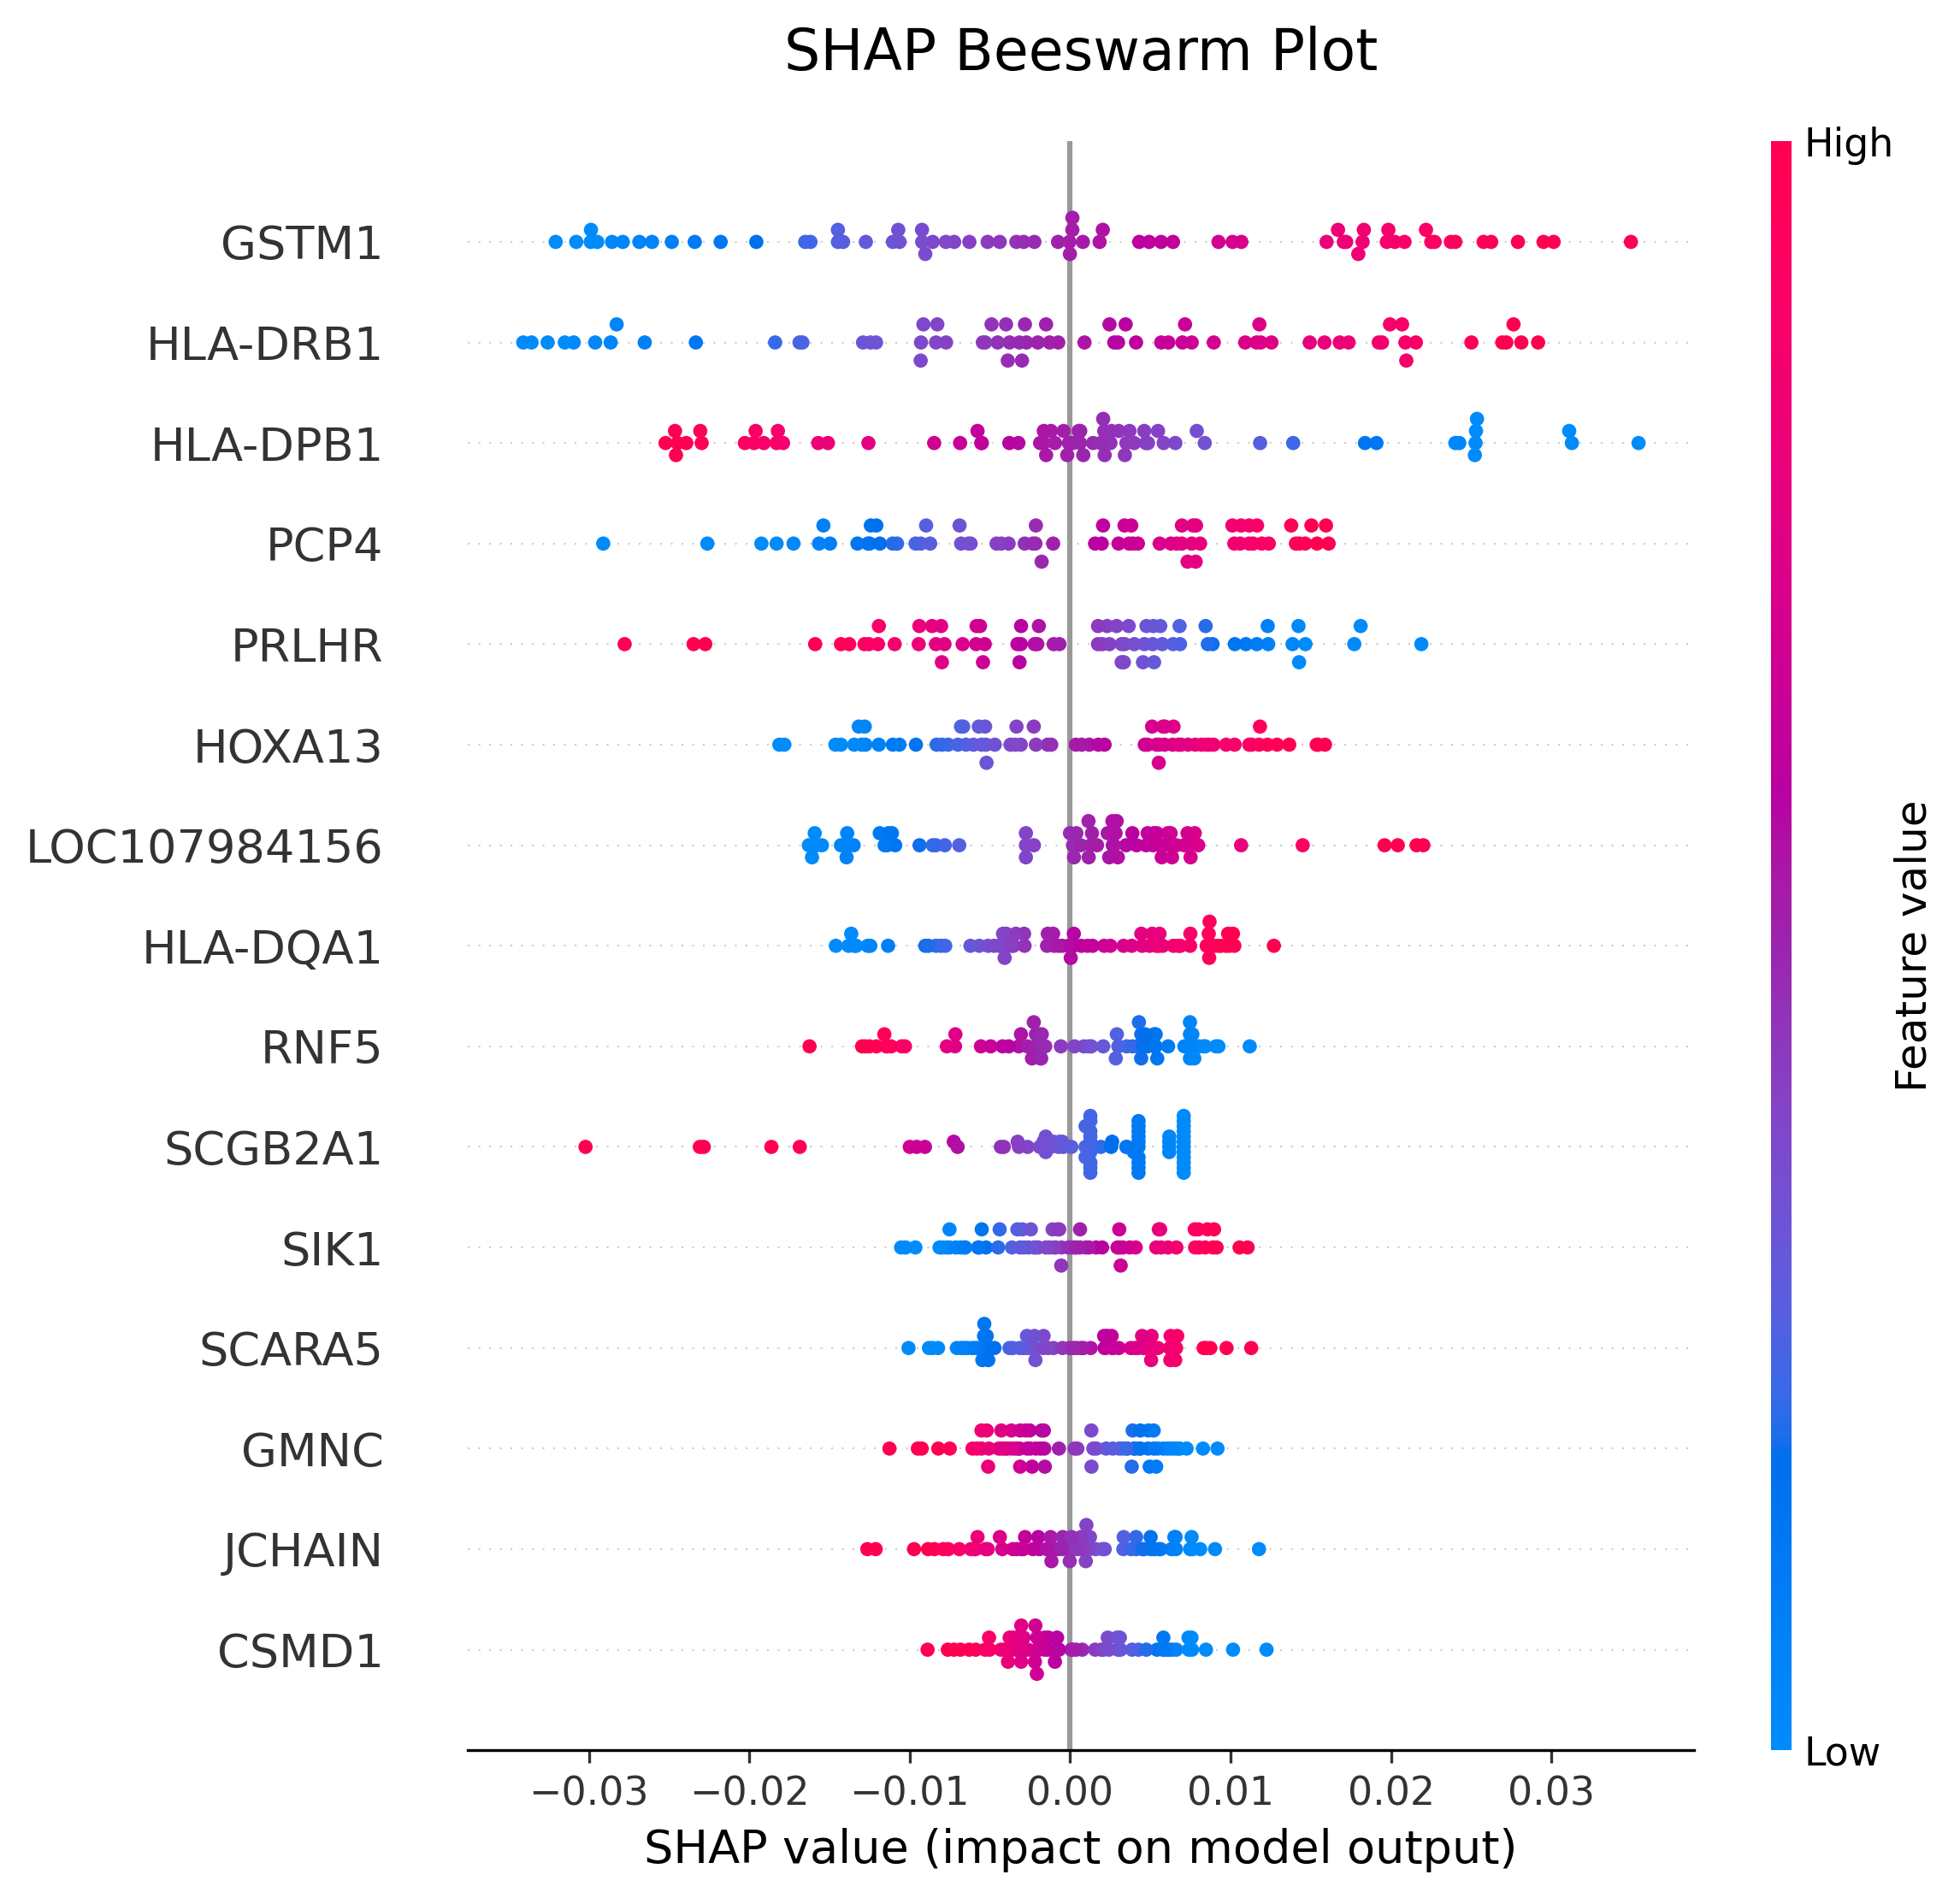

In [ ]:
import shap
import matplotlib.pyplot as plt

# ============================================================
# SHAP ANALYSIS
# ============================================================

print("\nCalculating SHAP values...")

# Use LinearExplainer for Logistic Regression
explainer = shap.LinearExplainer(
    model,
    X
)

shap_values = explainer.shap_values(X)

# ============================================================
# SHAP BEESWARM PLOT
# ============================================================

plt.figure(figsize=(10,7), dpi=300)

shap.summary_plot(
    shap_values,
    X,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Beeswarm Plot",
    fontsize=16,
    pad=20
)

plt.tight_layout()

# save high-resolution figure
plt.savefig(
    "shap_beeswarm_plot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# DATA LOADING (from your original code)
# ============================================================
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data = data.T

y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y = y.reset_index(drop=True)

data.reset_index(inplace=True)
data.drop("index", axis=1, inplace=True)

# Make first row the header
X = data
X.columns = X.iloc[0]
X = X.drop(X.index[0])

# Convert to numeric
X = X.apply(pd.to_numeric)

# Reset index for y to match X
y = y.reset_index(drop=True)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y value counts:\n{y.value_counts()}")

# ============================================================
# GRIDSEARCHCV SETUP
# ============================================================

# Repeated Stratified K-Fold
cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=10,
    random_state=42
)

# Metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# Parameter grid - testing C values with max_iter=1000
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10]
}

# Logistic Regression Model
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    penalty='l2',
    solver='liblinear'
)

# ============================================================
# GRID SEARCH CV
# ============================================================
print("\n" + "="*60)
print("Starting GridSearchCV with RepeatedStratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} (10 folds × 10 repeats)")
print(f"Parameter grid: {param_grid}")
print("="*60)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit='f1',  # refit based on F1 score
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# ============================================================
# SAVE FULL GRIDSEARCHCV RESULTS
# ============================================================
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv('logreg_gridsearchcv_full_results.csv', index=False)
print("\nSaved full GridSearchCV results as: logreg_gridsearchcv_full_results.csv")

# ============================================================
# BEST PARAMETERS AND SCORES
# ============================================================
print("\n" + "="*60)
print("BEST PARAMETERS")
print("="*60)
print(f"Best C: {grid_search.best_params_['C']}")
print(f"Best F1 Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

# Summary of best performance
best_params_rank = cv_results_df[cv_results_df['rank_test_f1'] == 1]
print("\nBest parameter ranking:")
print(best_params_rank[['params', 'mean_test_f1', 'std_test_f1', 'rank_test_f1']])

# ============================================================
# RESULTS FOR EACH FOLD AS CSV
# ============================================================
print("\n" + "="*60)
print("EXTRACTING FOLD-LEVEL RESULTS")
print("="*60)

# Get all fold results
fold_results = []

# cv.split returns (train_idx, test_idx) for each fold×repeat
fold_count = 0
for train_idx, test_idx in cv.split(X, y):
    fold_count += 1

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Train model with best C
    fold_model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=grid_search.best_params_['C'],
        penalty='l2',
        solver='liblinear'
    )
    fold_model.fit(X_train, y_train)

    # Predictions
    y_pred = fold_model.predict(X_test)
    y_prob = fold_model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    fold_row = {
        'fold_number': fold_count,
        'train_size': len(train_idx),
        'test_size': len(test_idx),
        'accuracy_test': accuracy_score(y_test, y_pred),
        'precision_test': precision_score(y_test, y_pred),
        'recall_test': recall_score(y_test, y_pred),
        'f1_test': f1_score(y_test, y_pred),
        'roc_auc_test': roc_auc_score(y_test, y_prob),
        'mcc_test': matthews_corrcoef(y_test, y_pred),
        'accuracy_train': accuracy_score(y_train, fold_model.predict(X_train)),
        'precision_train': precision_score(y_train, fold_model.predict(X_train)),
        'recall_train': recall_score(y_train, fold_model.predict(X_train)),
        'f1_train': f1_score(y_train, fold_model.predict(X_train)),
    }

    fold_results.append(fold_row)

# Create DataFrame and save
fold_results_df = pd.DataFrame(fold_results)
fold_results_df.to_csv('logreg_fold_results_best_C.csv', index=False)
print(f"\nSaved fold-level results for {fold_count} folds as: logreg_fold_results_best_C.csv")

# ============================================================
# RESULTS FOR EACH C VALUE ACROSS ALL FOLDS
# ============================================================
print("\n" + "="*60)
print("EXTRACTING RESULTS FOR EACH C VALUE ACROSS ALL FOLDS")
print("="*60)

all_c_fold_results = []

for c_idx, c_val in enumerate(param_grid['C']):
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        c_model = LogisticRegression(
            max_iter=1000,
            random_state=42,
            C=c_val,
            penalty='l2',
            solver='liblinear'
        )
        c_model.fit(X_train, y_train)

        y_pred = c_model.predict(X_test)
        y_prob = c_model.predict_proba(X_test)[:, 1]

        all_c_fold_results.append({
            'C_value': c_val,
            'fold_number': fold_idx + 1 + (c_idx * 100),  # unique fold per C
            'split_repeat': (fold_idx // 10) + 1,
            'fold_within_repeat': (fold_idx % 10) + 1,
            'train_size': len(train_idx),
            'test_size': len(test_idx),
            'accuracy_test': accuracy_score(y_test, y_pred),
            'precision_test': precision_score(y_test, y_pred),
            'recall_test': recall_score(y_test, y_pred),
            'f1_test': f1_score(y_test, y_pred),
            'roc_auc_test': roc_auc_score(y_test, y_prob),
            'mcc_test': matthews_corrcoef(y_test, y_pred),
            'accuracy_train': accuracy_score(y_train, c_model.predict(X_train)),
            'precision_train': precision_score(y_train, c_model.predict(X_train)),
            'recall_train': recall_score(y_train, c_model.predict(X_train)),
            'f1_train': f1_score(y_train, c_model.predict(X_train)),
        })

all_c_fold_df = pd.DataFrame(all_c_fold_results)
all_c_fold_df.to_csv('logreg_all_C_fold_results.csv', index=False)
print(f"\nSaved results for all {len(param_grid['C'])} C values × {fold_count} folds as: logreg_all_C_fold_results.csv")

# ============================================================
# SUMMARY TABLE FOR EACH C VALUE
# ============================================================
summary_rows = []
for c_val in param_grid['C']:
    c_data = all_c_fold_df[all_c_fold_df['C_value'] == c_val]

    summary_rows.append({
        'C': c_val,
        'accuracy_mean': c_data['accuracy_test'].mean(),
        'accuracy_sd': c_data['accuracy_test'].std(),
        'precision_mean': c_data['precision_test'].mean(),
        'precision_sd': c_data['precision_test'].std(),
        'recall_mean': c_data['recall_test'].mean(),
        'recall_sd': c_data['recall_test'].std(),
        'f1_mean': c_data['f1_test'].mean(),
        'f1_sd': c_data['f1_test'].std(),
        'roc_auc_mean': c_data['roc_auc_test'].mean(),
        'roc_auc_sd': c_data['roc_auc_test'].std(),
        'mcc_mean': c_data['mcc_test'].mean(),
        'mcc_sd': c_data['mcc_test'].std(),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('logreg_c_summary_by_fold.csv', index=False)
print("\nSaved C value summary as: logreg_c_summary_by_fold.csv")

# ============================================================
# PRINT SUMMARY
# ============================================================
print("\n" + "="*60)
print("SUMMARY BY C VALUE")
print("="*60)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(summary_df.to_string(index=False))

# ============================================================
# SAVE BEST MODEL
# ============================================================
with open("logistic_regression_best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
print("\nSaved best model as: logistic_regression_best_model.pkl")

print("\n" + "="*60)
print("ALL FILES SAVED:")
print("="*60)
print("1. logreg_gridsearchcv_full_results.csv - Full GridSearchCV results")
print("2. logreg_fold_results_best_C.csv - Fold results for best C")
print("3. logreg_all_C_fold_results.csv - All C values across all folds")
print("4. logreg_c_summary_by_fold.csv - Summary by C value")
print("5. logistic_regression_best_model.pkl - Best fitted model")

X shape: (71, 49)
y shape: (71,)
y value counts:
1.0    38
0.0    33
Name: count, dtype: int64

Starting GridSearchCV with RepeatedStratifiedKFold
Total CV splits: 100 (10 folds × 10 repeats)
Parameter grid: {'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10]}
Fitting 100 folds for each of 7 candidates, totalling 700 fits

Saved full GridSearchCV results as: logreg_gridsearchcv_full_results.csv

BEST PARAMETERS
Best C: 0.001
Best F1 Score: 1.0000

Best parameter ranking:
         params  mean_test_f1  std_test_f1  rank_test_f1
1  {'C': 0.001}           1.0          0.0             1
2   {'C': 0.01}           1.0          0.0             1
3    {'C': 0.1}           1.0          0.0             1
4      {'C': 1}           1.0          0.0             1
5      {'C': 5}           1.0          0.0             1
6     {'C': 10}           1.0          0.0             1

EXTRACTING FOLD-LEVEL RESULTS

Saved fold-level results for 100 folds as: logreg_fold_results_best_C.csv

EXTRACTING RESULTS FOR EACH

In [ ]:

import pandas as pd

data= pd.read_csv("BATCHY_LASSO_VAL.csv")

data = data.T

# Labels from row index
y = data.index.to_series().str[0].map({'C': 0, 'D': 1})
y = y.drop("Gene")
y = y.values.astype(int)

# Feature matrix
data = data.reset_index(drop=True)
data.columns = data.iloc[0]
data = data.drop(data.index[0]).apply(pd.to_numeric)
X = data
y_val = y
X_val = X

import pickle
import joblib
best_model = joblib.load('/content/logistic_regression_C0001_maxiter100.pkl')

# Open the file in read-binary mode



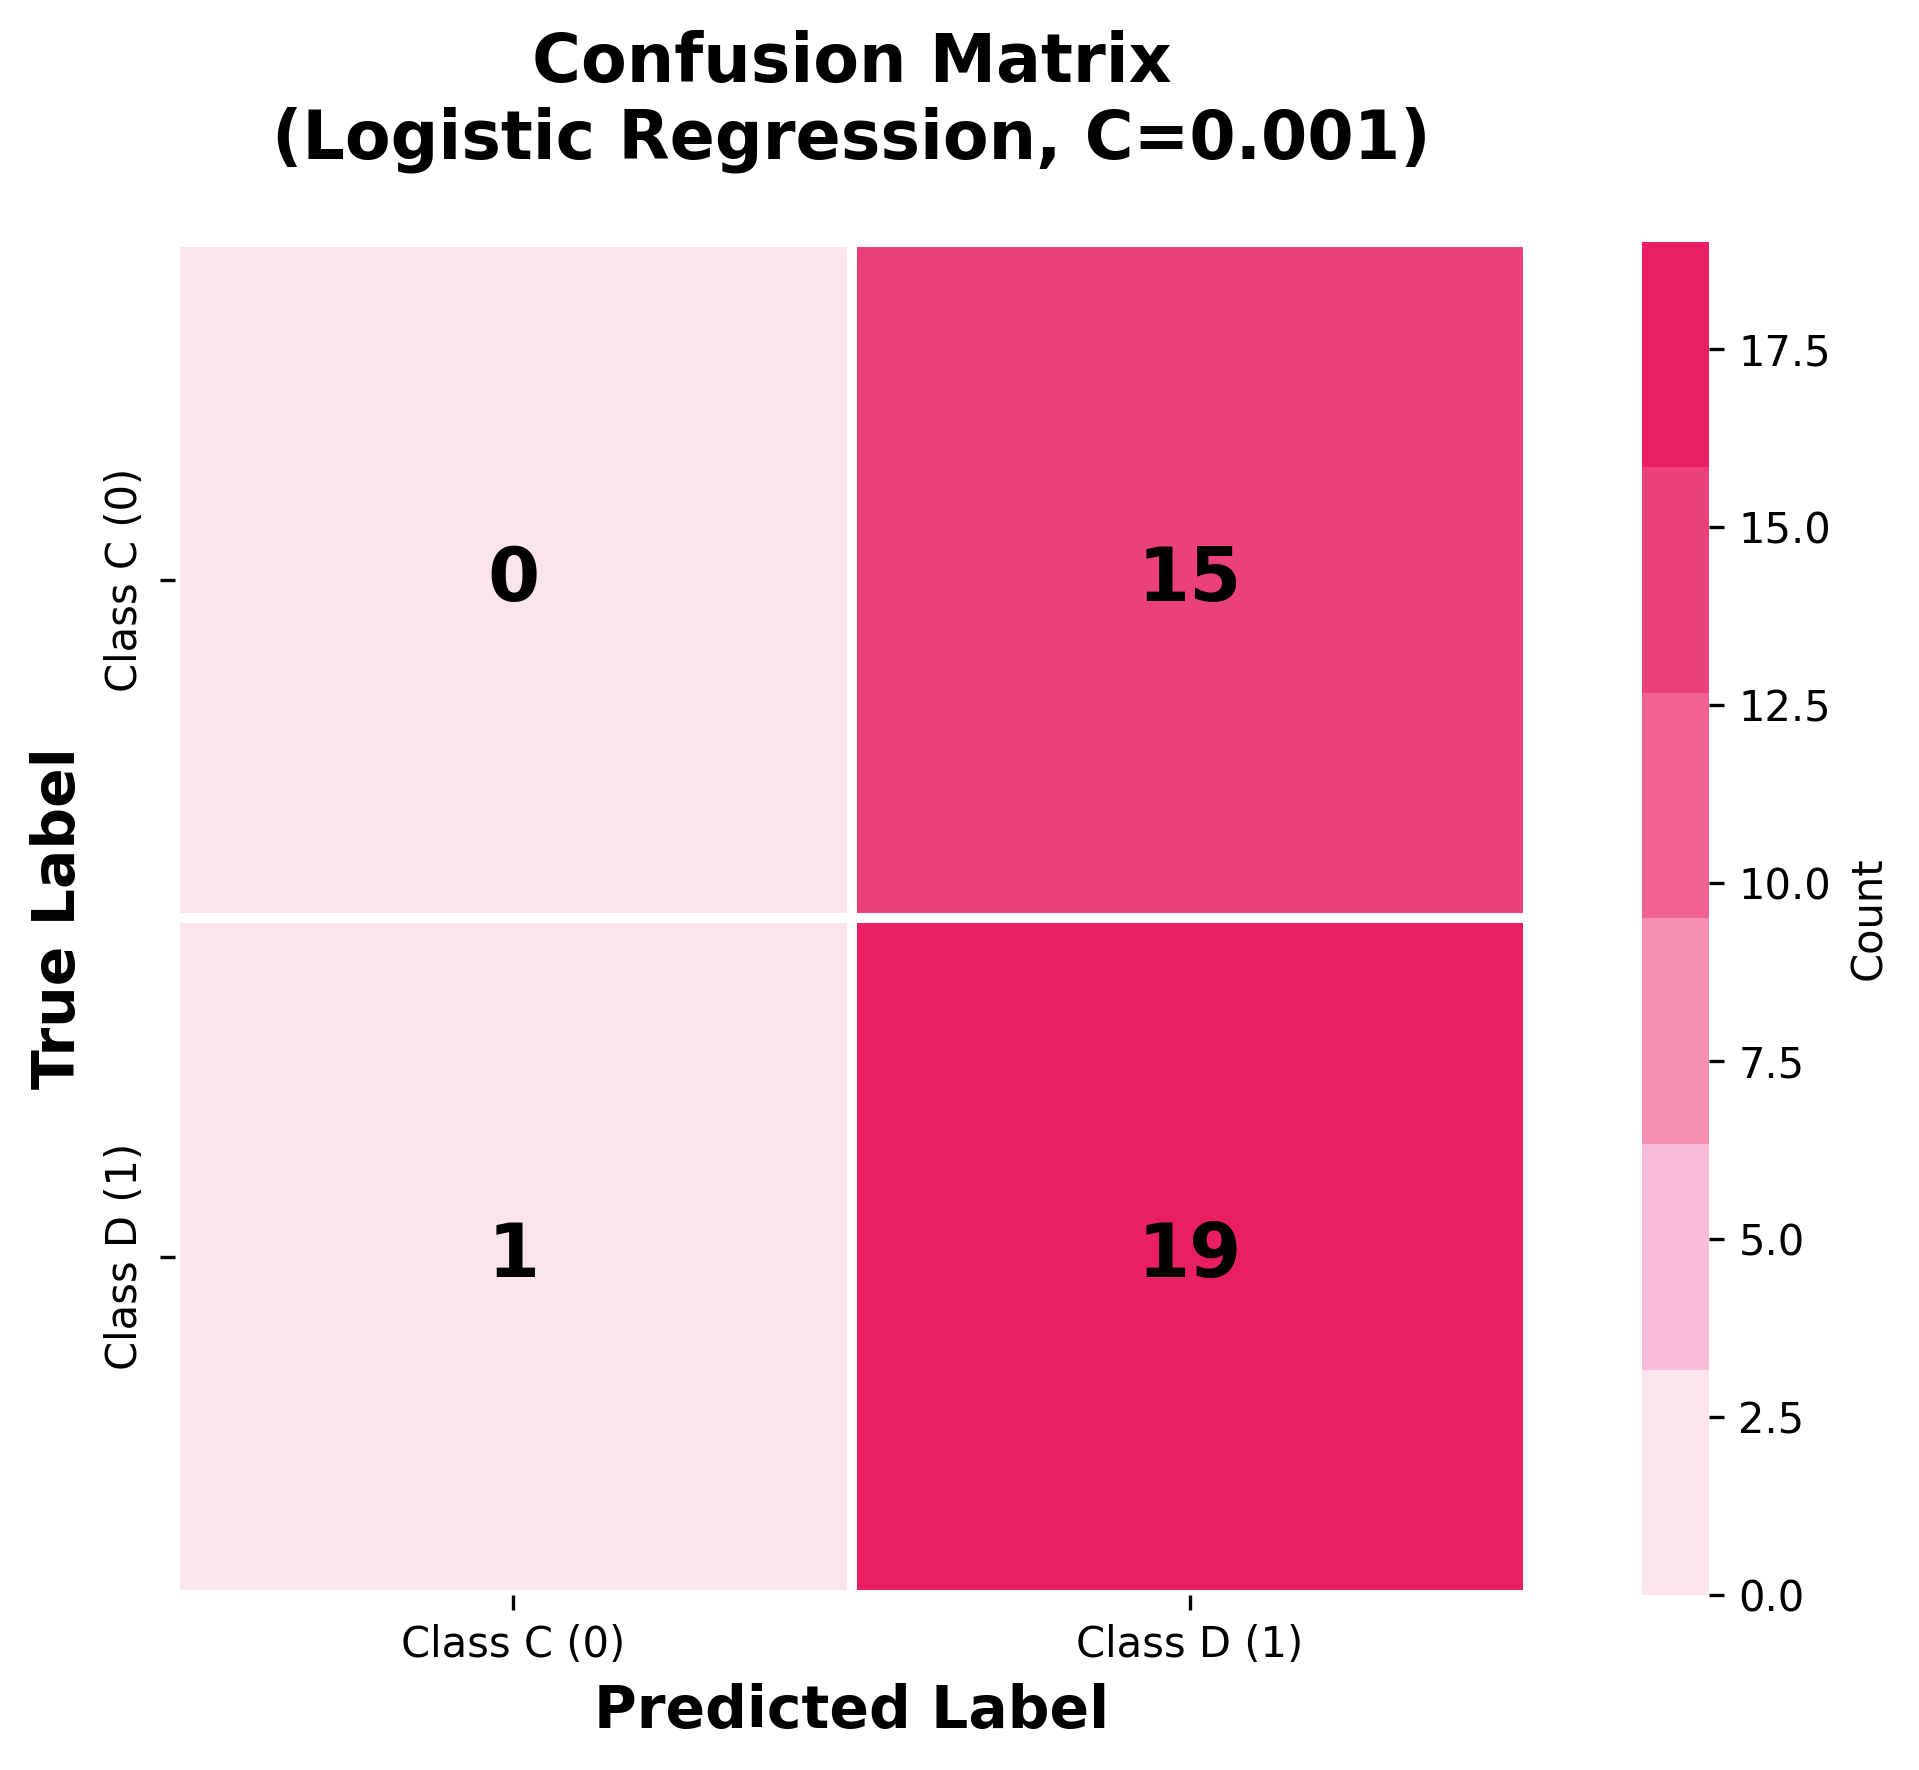


Saved as: confusion_matrix_pink.png

MODEL PERFORMANCE METRICS
Accuracy:  0.5429
Precision: 0.5588
Recall:    0.9500
F1-Score:  0.7037
MCC:       -0.1485

CONFUSION MATRIX (Raw Counts)
                    Predicted C    Predicted D
True Class C                 0            15
True Class D                 1            19


In [ ]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

# ============================================================
# LOAD BEST MODEL
# ============================================================
with open("logistic_regression_best_model.pkl", "rb") as f:
    best_model = pickle.load(f)

# ============================================================
# MAKE PREDICTIONS
# ============================================================
y_pred = best_model.predict(X)

# ============================================================
# COMPUTE CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y, y_pred)

# ============================================================
# PLOT ONE PINK CONFUSION MATRIX (BOXES ARE PINK)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Sweet pleasing pink colormap for the BOXES
pink_cmap = sns.color_palette(['#fce4ec', '#f8bbd9', '#f48fb1', '#f06292', '#ec407a', '#e91e63'], as_cmap=True)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=pink_cmap,       # PINK boxes
    cbar=True,           # Keep colorbar
    cbar_kws={'label': 'Count'},  # Colorbar label
    square=True,
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 18, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.title(
    f'Confusion Matrix\n(Logistic Regression, C={best_model.get_params()["C"]})',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.savefig('confusion_matrix_pink.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\nSaved as: confusion_matrix_pink.png")

# ============================================================
# PRINT METRICS
# ============================================================
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
mcc = matthews_corrcoef(y, y_pred)

print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")

print("\n" + "="*60)
print("CONFUSION MATRIX (Raw Counts)")
print("="*60)
print(f"                    Predicted C    Predicted D")
print(f"True Class C        {cm[0,0]:>10d}    {cm[0,1]:>10d}")
print(f"True Class D        {cm[1,0]:>10d}    {cm[1,1]:>10d}")

In [ ]:
import numpy as np
import pandas as pd
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# DATA LOADING
# ============================================================
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data = data.T

y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y = y.reset_index(drop=True)

data.reset_index(inplace=True)
data.drop("index", axis=1, inplace=True)

# Make first row the header
X = data
X.columns = X.iloc[0]
X = X.drop(X.index[0])

# Convert to numeric
X = X.apply(pd.to_numeric)

# Reset index for y to match X
y = y.reset_index(drop=True)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y value counts:\n{y.value_counts()}")

# ============================================================
# GRIDSEARCHCV SETUP
# ============================================================

# Repeated Stratified K-Fold
cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=10,
    random_state=42
)

# Metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# Parameter grid — C × max_iter
param_grid = {
    'C':        [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
}

# Logistic Regression base model
model = LogisticRegression(
    random_state=42,
    penalty='l2',
    solver='liblinear'
)

# ============================================================
# GRID SEARCH CV
# ============================================================
total_combos = len(param_grid['C']) * len(param_grid['max_iter'])
print("\n" + "="*60)
print("Starting GridSearchCV with RepeatedStratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} (10 folds × 10 repeats)")
print(f"Parameter grid: {total_combos} combinations  "
      f"(C × max_iter = {len(param_grid['C'])} × {len(param_grid['max_iter'])})")
print(f"Refit metric: accuracy")
print("="*60)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit='accuracy',          # ← select best model by accuracy
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# ============================================================
# SAVE FULL GRIDSEARCHCV RESULTS
# ============================================================
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv('/content/drive/MyDrive/LR/10_10/logreg_gridsearchcv_full_results.csv', index=False)
print("\nSaved: logreg_gridsearchcv_full_results.csv")

# ============================================================
# BEST PARAMETERS AND SCORES
# ============================================================
best_C        = grid_search.best_params_['C']
best_max_iter = grid_search.best_params_['max_iter']

print("\n" + "="*60)
print("BEST PARAMETERS (by Accuracy)")
print("="*60)
print(f"  Best C         : {best_C}")
print(f"  Best max_iter  : {best_max_iter}")
print(f"  Best Accuracy  : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

best_row = cv_results_df[cv_results_df['rank_test_accuracy'] == 1]
print("\nBest-parameter row summary:")
print(best_row[['params',
                'mean_test_accuracy', 'std_test_accuracy',
                'mean_test_f1',       'std_test_f1',
                'rank_test_accuracy']].to_string(index=False))

# ============================================================
# FOLD-LEVEL RESULTS FOR THE BEST (C, max_iter) COMBINATION
# ============================================================
print("\n" + "="*60)
print("EXTRACTING FOLD-LEVEL RESULTS FOR BEST PARAMS")
print("="*60)

fold_results = []
for fold_count, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    fold_model = LogisticRegression(
        random_state=42,
        penalty='l2',
        solver='liblinear',
        C=best_C,
        max_iter=best_max_iter
    )
    fold_model.fit(X_train, y_train)

    y_pred      = fold_model.predict(X_test)
    y_prob      = fold_model.predict_proba(X_test)[:, 1]
    y_pred_tr   = fold_model.predict(X_train)

    fold_results.append({
        'fold_number'     : fold_count,
        'repeat'          : (fold_count - 1) // 10 + 1,
        'fold_in_repeat'  : (fold_count - 1) % 10 + 1,
        'train_size'      : len(train_idx),
        'test_size'       : len(test_idx),
        'accuracy_test'   : accuracy_score(y_test, y_pred),
        'precision_test'  : precision_score(y_test, y_pred, zero_division=0),
        'recall_test'     : recall_score(y_test, y_pred, zero_division=0),
        'f1_test'         : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc_test'    : roc_auc_score(y_test, y_prob),
        'mcc_test'        : matthews_corrcoef(y_test, y_pred),
        'accuracy_train'  : accuracy_score(y_train, y_pred_tr),
        'precision_train' : precision_score(y_train, y_pred_tr, zero_division=0),
        'recall_train'    : recall_score(y_train, y_pred_tr, zero_division=0),
        'f1_train'        : f1_score(y_train, y_pred_tr, zero_division=0),
    })

fold_df = pd.DataFrame(fold_results)
fold_df.to_csv('/content/drive/MyDrive/LR/10_10/logreg_fold_results_best_params.csv', index=False)
print(f"Saved {fold_count} folds → logreg_fold_results_best_params.csv")

# ============================================================
# RESULTS FOR EVERY (C, max_iter) COMBINATION ACROSS ALL FOLDS
# ============================================================
print("\n" + "="*60)
print("EXTRACTING RESULTS FOR ALL (C, max_iter) COMBINATIONS")
print("="*60)

splits = list(cv.split(X, y))          # materialise once to reuse
all_combo_results = []

for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        for fold_idx, (train_idx, test_idx) in enumerate(splits):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            m = LogisticRegression(
                random_state=42,
                penalty='l2',
                solver='liblinear',
                C=c_val,
                max_iter=iter_val
            )
            m.fit(X_train, y_train)

            y_pred    = m.predict(X_test)
            y_prob    = m.predict_proba(X_test)[:, 1]
            y_pred_tr = m.predict(X_train)

            all_combo_results.append({
                'C'               : c_val,
                'max_iter'        : iter_val,
                'fold_number'     : fold_idx + 1,
                'repeat'          : fold_idx // 10 + 1,
                'fold_in_repeat'  : fold_idx % 10 + 1,
                'train_size'      : len(train_idx),
                'test_size'       : len(test_idx),
                'accuracy_test'   : accuracy_score(y_test, y_pred),
                'precision_test'  : precision_score(y_test, y_pred, zero_division=0),
                'recall_test'     : recall_score(y_test, y_pred, zero_division=0),
                'f1_test'         : f1_score(y_test, y_pred, zero_division=0),
                'roc_auc_test'    : roc_auc_score(y_test, y_prob),
                'mcc_test'        : matthews_corrcoef(y_test, y_pred),
                'accuracy_train'  : accuracy_score(y_train, y_pred_tr),
                'precision_train' : precision_score(y_train, y_pred_tr, zero_division=0),
                'recall_train'    : recall_score(y_train, y_pred_tr, zero_division=0),
                'f1_train'        : f1_score(y_train, y_pred_tr, zero_division=0),
            })

all_combo_df = pd.DataFrame(all_combo_results)
all_combo_df.to_csv('/content/drive/MyDrive/LR/10_10/logreg_all_combos_fold_results.csv', index=False)
print(f"Saved {len(all_combo_results)} rows → logreg_all_combos_fold_results.csv")

# ============================================================
# SUMMARY TABLE — mean ± SD for every (C, max_iter) combination
# ============================================================
summary_rows = []
for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        sub = all_combo_df[
            (all_combo_df['C'] == c_val) &
            (all_combo_df['max_iter'] == iter_val)
        ]
        summary_rows.append({
            'C'             : c_val,
            'max_iter'      : iter_val,
            'accuracy_mean' : sub['accuracy_test'].mean(),
            'accuracy_sd'   : sub['accuracy_test'].std(),
            'precision_mean': sub['precision_test'].mean(),
            'precision_sd'  : sub['precision_test'].std(),
            'recall_mean'   : sub['recall_test'].mean(),
            'recall_sd'     : sub['recall_test'].std(),
            'f1_mean'       : sub['f1_test'].mean(),
            'f1_sd'         : sub['f1_test'].std(),
            'roc_auc_mean'  : sub['roc_auc_test'].mean(),
            'roc_auc_sd'    : sub['roc_auc_test'].std(),
            'mcc_mean'      : sub['mcc_test'].mean(),
            'mcc_sd'        : sub['mcc_test'].std(),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('/content/drive/MyDrive/LR/10_10/logreg_combo_summary.csv', index=False)
print("Saved: logreg_combo_summary.csv")

# ============================================================
# PIVOT TABLE — accuracy_mean as a (C × max_iter) matrix
# ============================================================
pivot_acc = summary_df.pivot(index='C', columns='max_iter', values='accuracy_mean')
pivot_acc.to_csv('/content/drive/MyDrive/LR/10_10/logreg_pivot_accuracy_mean.csv')
print("Saved: logreg_pivot_accuracy_mean.csv")

# ============================================================
# PRINT SUMMARY
# ============================================================
print("\n" + "="*60)
print("SUMMARY — Mean Accuracy by (C, max_iter)")
print("="*60)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print(pivot_acc.to_string())

print("\n" + "="*60)
print("TOP 10 COMBINATIONS BY ACCURACY")
print("="*60)
top10 = (summary_df
         .sort_values('accuracy_mean', ascending=False)
         .head(10)[['C', 'max_iter',
                    'accuracy_mean', 'accuracy_sd',
                    'f1_mean', 'f1_sd',
                    'roc_auc_mean', 'mcc_mean']])
print(top10.to_string(index=False))

# ============================================================
# SAVE BEST MODEL
# ============================================================
with open("/content/drive/MyDrive/LR/10_10/logistic_regression_best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
print("\nSaved: logistic_regression_best_model.pkl")

# ============================================================
# FILE SUMMARY
# ============================================================
print("\n" + "="*60)
print("ALL FILES SAVED")
print("="*60)
print("1. logreg_gridsearchcv_full_results.csv  — Raw GridSearchCV output (all splits, all metrics)")
print("2. logreg_fold_results_best_params.csv   — 100 fold rows for best (C, max_iter)")
print("3. logreg_all_combos_fold_results.csv    — 70 combos × 100 folds = 7 000 rows")
print("4. logreg_combo_summary.csv              — Mean ± SD for every (C, max_iter)")
print("5. logreg_pivot_accuracy_mean.csv        — C × max_iter accuracy matrix")
print("6. logistic_regression_best_model.pkl    — Best fitted model (refitted on full data)")
print(f"\nBest model: C={best_C}, max_iter={best_max_iter}, "
      f"CV Accuracy={grid_search.best_score_:.4f}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/lasso_batchy.csv'

In [ ]:
import numpy as np
import pandas as pd
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# DATA LOADING
# ============================================================
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data = data.T

y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y = y.reset_index(drop=True)

data.reset_index(inplace=True)
data.drop("index", axis=1, inplace=True)

# Make first row the header
X = data
X.columns = X.iloc[0]
X = X.drop(X.index[0])

# Convert to numeric
X = X.apply(pd.to_numeric)

# Reset index for y to match X
y = y.reset_index(drop=True)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y value counts:\n{y.value_counts()}")

# ============================================================
# GRIDSEARCHCV SETUP
# ============================================================

# Repeated Stratified K-Fold
cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=5,
    random_state=42
)

# Metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# Parameter grid — C × max_iter
param_grid = {
    'C':        [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
}

# Logistic Regression base model
model = LogisticRegression(
    random_state=42,
    penalty='l2',
    solver='liblinear'
)

# ============================================================
# GRID SEARCH CV
# ============================================================
total_combos = len(param_grid['C']) * len(param_grid['max_iter'])
print("\n" + "="*60)
print("Starting GridSearchCV with RepeatedStratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} (10 folds × 10 repeats)")
print(f"Parameter grid: {total_combos} combinations  "
      f"(C × max_iter = {len(param_grid['C'])} × {len(param_grid['max_iter'])})")
print(f"Refit metric: accuracy")
print("="*60)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit='accuracy',          # ← select best model by accuracy
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# ============================================================
# SAVE FULL GRIDSEARCHCV RESULTS
# ============================================================
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv('/content/drive/MyDrive/LR/10_5/logreg_gridsearchcv_full_results.csv', index=False)
print("\nSaved: logreg_gridsearchcv_full_results.csv")

# ============================================================
# BEST PARAMETERS AND SCORES
# ============================================================
best_C        = grid_search.best_params_['C']
best_max_iter = grid_search.best_params_['max_iter']

print("\n" + "="*60)
print("BEST PARAMETERS (by Accuracy)")
print("="*60)
print(f"  Best C         : {best_C}")
print(f"  Best max_iter  : {best_max_iter}")
print(f"  Best Accuracy  : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

best_row = cv_results_df[cv_results_df['rank_test_accuracy'] == 1]
print("\nBest-parameter row summary:")
print(best_row[['params',
                'mean_test_accuracy', 'std_test_accuracy',
                'mean_test_f1',       'std_test_f1',
                'rank_test_accuracy']].to_string(index=False))

# ============================================================
# FOLD-LEVEL RESULTS FOR THE BEST (C, max_iter) COMBINATION
# ============================================================
print("\n" + "="*60)
print("EXTRACTING FOLD-LEVEL RESULTS FOR BEST PARAMS")
print("="*60)

fold_results = []
for fold_count, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    fold_model = LogisticRegression(
        random_state=42,
        penalty='l2',
        solver='liblinear',
        C=best_C,
        max_iter=best_max_iter
    )
    fold_model.fit(X_train, y_train)

    y_pred      = fold_model.predict(X_test)
    y_prob      = fold_model.predict_proba(X_test)[:, 1]
    y_pred_tr   = fold_model.predict(X_train)

    fold_results.append({
        'fold_number'     : fold_count,
        'repeat'          : (fold_count - 1) // 10 + 1,
        'fold_in_repeat'  : (fold_count - 1) % 10 + 1,
        'train_size'      : len(train_idx),
        'test_size'       : len(test_idx),
        'accuracy_test'   : accuracy_score(y_test, y_pred),
        'precision_test'  : precision_score(y_test, y_pred, zero_division=0),
        'recall_test'     : recall_score(y_test, y_pred, zero_division=0),
        'f1_test'         : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc_test'    : roc_auc_score(y_test, y_prob),
        'mcc_test'        : matthews_corrcoef(y_test, y_pred),
        'accuracy_train'  : accuracy_score(y_train, y_pred_tr),
        'precision_train' : precision_score(y_train, y_pred_tr, zero_division=0),
        'recall_train'    : recall_score(y_train, y_pred_tr, zero_division=0),
        'f1_train'        : f1_score(y_train, y_pred_tr, zero_division=0),
    })

fold_df = pd.DataFrame(fold_results)
fold_df.to_csv('/content/drive/MyDrive/LR/10_5/logreg_fold_results_best_params.csv', index=False)
print(f"Saved {fold_count} folds → logreg_fold_results_best_params.csv")

# ============================================================
# RESULTS FOR EVERY (C, max_iter) COMBINATION ACROSS ALL FOLDS
# ============================================================
print("\n" + "="*60)
print("EXTRACTING RESULTS FOR ALL (C, max_iter) COMBINATIONS")
print("="*60)

splits = list(cv.split(X, y))          # materialise once to reuse
all_combo_results = []

for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        for fold_idx, (train_idx, test_idx) in enumerate(splits):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            m = LogisticRegression(
                random_state=42,
                penalty='l2',
                solver='liblinear',
                C=c_val,
                max_iter=iter_val
            )
            m.fit(X_train, y_train)

            y_pred    = m.predict(X_test)
            y_prob    = m.predict_proba(X_test)[:, 1]
            y_pred_tr = m.predict(X_train)

            all_combo_results.append({
                'C'               : c_val,
                'max_iter'        : iter_val,
                'fold_number'     : fold_idx + 1,
                'repeat'          : fold_idx // 10 + 1,
                'fold_in_repeat'  : fold_idx % 10 + 1,
                'train_size'      : len(train_idx),
                'test_size'       : len(test_idx),
                'accuracy_test'   : accuracy_score(y_test, y_pred),
                'precision_test'  : precision_score(y_test, y_pred, zero_division=0),
                'recall_test'     : recall_score(y_test, y_pred, zero_division=0),
                'f1_test'         : f1_score(y_test, y_pred, zero_division=0),
                'roc_auc_test'    : roc_auc_score(y_test, y_prob),
                'mcc_test'        : matthews_corrcoef(y_test, y_pred),
                'accuracy_train'  : accuracy_score(y_train, y_pred_tr),
                'precision_train' : precision_score(y_train, y_pred_tr, zero_division=0),
                'recall_train'    : recall_score(y_train, y_pred_tr, zero_division=0),
                'f1_train'        : f1_score(y_train, y_pred_tr, zero_division=0),
            })

all_combo_df = pd.DataFrame(all_combo_results)
all_combo_df.to_csv('/content/drive/MyDrive/LR/10_5/logreg_all_combos_fold_results.csv', index=False)
print(f"Saved {len(all_combo_results)} rows → logreg_all_combos_fold_results.csv")

# ============================================================
# SUMMARY TABLE — mean ± SD for every (C, max_iter) combination
# ============================================================
summary_rows = []
for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        sub = all_combo_df[
            (all_combo_df['C'] == c_val) &
            (all_combo_df['max_iter'] == iter_val)
        ]
        summary_rows.append({
            'C'             : c_val,
            'max_iter'      : iter_val,
            'accuracy_mean' : sub['accuracy_test'].mean(),
            'accuracy_sd'   : sub['accuracy_test'].std(),
            'precision_mean': sub['precision_test'].mean(),
            'precision_sd'  : sub['precision_test'].std(),
            'recall_mean'   : sub['recall_test'].mean(),
            'recall_sd'     : sub['recall_test'].std(),
            'f1_mean'       : sub['f1_test'].mean(),
            'f1_sd'         : sub['f1_test'].std(),
            'roc_auc_mean'  : sub['roc_auc_test'].mean(),
            'roc_auc_sd'    : sub['roc_auc_test'].std(),
            'mcc_mean'      : sub['mcc_test'].mean(),
            'mcc_sd'        : sub['mcc_test'].std(),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('/content/drive/MyDrive/LR/10_5/logreg_combo_summary.csv', index=False)
print("Saved: logreg_combo_summary.csv")

# ============================================================
# PIVOT TABLE — accuracy_mean as a (C × max_iter) matrix
# ============================================================
pivot_acc = summary_df.pivot(index='C', columns='max_iter', values='accuracy_mean')
pivot_acc.to_csv('/content/drive/MyDrive/LR/10_5/logreg_pivot_accuracy_mean.csv')
print("Saved: logreg_pivot_accuracy_mean.csv")

# ============================================================
# PRINT SUMMARY
# ============================================================
print("\n" + "="*60)
print("SUMMARY — Mean Accuracy by (C, max_iter)")
print("="*60)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print(pivot_acc.to_string())

print("\n" + "="*60)
print("TOP 10 COMBINATIONS BY ACCURACY")
print("="*60)
top10 = (summary_df
         .sort_values('accuracy_mean', ascending=False)
         .head(10)[['C', 'max_iter',
                    'accuracy_mean', 'accuracy_sd',
                    'f1_mean', 'f1_sd',
                    'roc_auc_mean', 'mcc_mean']])
print(top10.to_string(index=False))

# ============================================================
# SAVE BEST MODEL

# ============================================================
with open("/content/drive/MyDrive/LR/10_5/logistic_regression_best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
print("\nSaved: logistic_regression_best_model.pkl")

# ============================================================
# FILE SUMMARY
# ============================================================
print("\n" + "="*60)
print("ALL FILES SAVED")
print("="*60)
print("1. logreg_gridsearchcv_full_results.csv  — Raw GridSearchCV output (all splits, all metrics)")
print("2. logreg_fold_results_best_params.csv   — 100 fold rows for best (C, max_iter)")
print("3. logreg_all_combos_fold_results.csv    — 70 combos × 100 folds = 7 000 rows")
print("4. logreg_combo_summary.csv              — Mean ± SD for every (C, max_iter)")
print("5. logreg_pivot_accuracy_mean.csv        — C × max_iter accuracy matrix")
print("6. logistic_regression_best_model.pkl    — Best fitted model (refitted on full data)")
print(f"\nBest model: C={best_C}, max_iter={best_max_iter}, "
      f"CV Accuracy={grid_search.best_score_:.4f}")

X shape: (71, 49)
y shape: (71,)
y value counts:
1.0000    38
0.0000    33
Name: count, dtype: int64

Starting GridSearchCV with RepeatedStratifiedKFold
Total CV splits: 50 (10 folds × 10 repeats)
Parameter grid: 70 combinations  (C × max_iter = 7 × 10)
Refit metric: accuracy
Fitting 50 folds for each of 70 candidates, totalling 3500 fits

Saved: logreg_gridsearchcv_full_results.csv

BEST PARAMETERS (by Accuracy)
  Best C         : 0.001
  Best max_iter  : 100
  Best Accuracy  : 1.0000

Best-parameter row summary:
                        params  mean_test_accuracy  std_test_accuracy  mean_test_f1  std_test_f1  rank_test_accuracy
 {'C': 0.001, 'max_iter': 100}              1.0000             0.0000        1.0000       0.0000                   1
 {'C': 0.001, 'max_iter': 200}              1.0000             0.0000        1.0000       0.0000                   1
 {'C': 0.001, 'max_iter': 300}              1.0000             0.0000        1.0000       0.0000                   1
 {'C': 0.001

In [ ]:
import numpy as np
import pandas as pd
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# DATA LOADING
# ============================================================
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data = data.T

y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y = y.reset_index(drop=True)

data.reset_index(inplace=True)
data.drop("index", axis=1, inplace=True)

# Make first row the header
X = data
X.columns = X.iloc[0]
X = X.drop(X.index[0])

# Convert to numeric
X = X.apply(pd.to_numeric)

# Reset index for y to match X
y = y.reset_index(drop=True)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y value counts:\n{y.value_counts()}")

# ============================================================
# GRIDSEARCHCV SETUP
# ============================================================

# Repeated Stratified K-Fold
cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=2,
    random_state=42
)

# Metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# Parameter grid — C × max_iter
param_grid = {
    'C':        [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
}

# Logistic Regression base model
model = LogisticRegression(
    random_state=42,
    penalty='l2',
    solver='liblinear'
)

# ============================================================
# GRID SEARCH CV
# ============================================================
total_combos = len(param_grid['C']) * len(param_grid['max_iter'])
print("\n" + "="*60)
print("Starting GridSearchCV with RepeatedStratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} (10 folds × 10 repeats)")
print(f"Parameter grid: {total_combos} combinations  "
      f"(C × max_iter = {len(param_grid['C'])} × {len(param_grid['max_iter'])})")
print(f"Refit metric: accuracy")
print("="*60)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit='accuracy',          # ← select best model by accuracy
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# ============================================================
# SAVE FULL GRIDSEARCHCV RESULTS
# ============================================================
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv('/content/drive/MyDrive/LR/10_2/logreg_gridsearchcv_full_results.csv', index=False)
print("\nSaved: logreg_gridsearchcv_full_results.csv")

# ============================================================
# BEST PARAMETERS AND SCORES
# ============================================================
best_C        = grid_search.best_params_['C']
best_max_iter = grid_search.best_params_['max_iter']

print("\n" + "="*60)
print("BEST PARAMETERS (by Accuracy)")
print("="*60)
print(f"  Best C         : {best_C}")
print(f"  Best max_iter  : {best_max_iter}")
print(f"  Best Accuracy  : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

best_row = cv_results_df[cv_results_df['rank_test_accuracy'] == 1]
print("\nBest-parameter row summary:")
print(best_row[['params',
                'mean_test_accuracy', 'std_test_accuracy',
                'mean_test_f1',       'std_test_f1',
                'rank_test_accuracy']].to_string(index=False))

# ============================================================
# FOLD-LEVEL RESULTS FOR THE BEST (C, max_iter) COMBINATION
# ============================================================
print("\n" + "="*60)
print("EXTRACTING FOLD-LEVEL RESULTS FOR BEST PARAMS")
print("="*60)

fold_results = []
for fold_count, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    fold_model = LogisticRegression(
        random_state=42,
        penalty='l2',
        solver='liblinear',
        C=best_C,
        max_iter=best_max_iter
    )
    fold_model.fit(X_train, y_train)

    y_pred      = fold_model.predict(X_test)
    y_prob      = fold_model.predict_proba(X_test)[:, 1]
    y_pred_tr   = fold_model.predict(X_train)

    fold_results.append({
        'fold_number'     : fold_count,
        'repeat'          : (fold_count - 1) // 10 + 1,
        'fold_in_repeat'  : (fold_count - 1) % 10 + 1,
        'train_size'      : len(train_idx),
        'test_size'       : len(test_idx),
        'accuracy_test'   : accuracy_score(y_test, y_pred),
        'precision_test'  : precision_score(y_test, y_pred, zero_division=0),
        'recall_test'     : recall_score(y_test, y_pred, zero_division=0),
        'f1_test'         : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc_test'    : roc_auc_score(y_test, y_prob),
        'mcc_test'        : matthews_corrcoef(y_test, y_pred),
        'accuracy_train'  : accuracy_score(y_train, y_pred_tr),
        'precision_train' : precision_score(y_train, y_pred_tr, zero_division=0),
        'recall_train'    : recall_score(y_train, y_pred_tr, zero_division=0),
        'f1_train'        : f1_score(y_train, y_pred_tr, zero_division=0),
    })

fold_df = pd.DataFrame(fold_results)
fold_df.to_csv('/content/drive/MyDrive/LR/10_2/logreg_fold_results_best_params.csv', index=False)
print(f"Saved {fold_count} folds → logreg_fold_results_best_params.csv")

# ============================================================
# RESULTS FOR EVERY (C, max_iter) COMBINATION ACROSS ALL FOLDS
# ============================================================
print("\n" + "="*60)
print("EXTRACTING RESULTS FOR ALL (C, max_iter) COMBINATIONS")
print("="*60)

splits = list(cv.split(X, y))          # materialise once to reuse
all_combo_results = []

for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        for fold_idx, (train_idx, test_idx) in enumerate(splits):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            m = LogisticRegression(
                random_state=42,
                penalty='l2',
                solver='liblinear',
                C=c_val,
                max_iter=iter_val
            )
            m.fit(X_train, y_train)

            y_pred    = m.predict(X_test)
            y_prob    = m.predict_proba(X_test)[:, 1]
            y_pred_tr = m.predict(X_train)

            all_combo_results.append({
                'C'               : c_val,
                'max_iter'        : iter_val,
                'fold_number'     : fold_idx + 1,
                'repeat'          : fold_idx // 10 + 1,
                'fold_in_repeat'  : fold_idx % 10 + 1,
                'train_size'      : len(train_idx),
                'test_size'       : len(test_idx),
                'accuracy_test'   : accuracy_score(y_test, y_pred),
                'precision_test'  : precision_score(y_test, y_pred, zero_division=0),
                'recall_test'     : recall_score(y_test, y_pred, zero_division=0),
                'f1_test'         : f1_score(y_test, y_pred, zero_division=0),
                'roc_auc_test'    : roc_auc_score(y_test, y_prob),
                'mcc_test'        : matthews_corrcoef(y_test, y_pred),
                'accuracy_train'  : accuracy_score(y_train, y_pred_tr),
                'precision_train' : precision_score(y_train, y_pred_tr, zero_division=0),
                'recall_train'    : recall_score(y_train, y_pred_tr, zero_division=0),
                'f1_train'        : f1_score(y_train, y_pred_tr, zero_division=0),
            })

all_combo_df = pd.DataFrame(all_combo_results)
all_combo_df.to_csv('/content/drive/MyDrive/LR/10_2/logreg_all_combos_fold_results.csv', index=False)
print(f"Saved {len(all_combo_results)} rows → logreg_all_combos_fold_results.csv")

# ============================================================
# SUMMARY TABLE — mean ± SD for every (C, max_iter) combination
# ============================================================
summary_rows = []
for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        sub = all_combo_df[
            (all_combo_df['C'] == c_val) &
            (all_combo_df['max_iter'] == iter_val)
        ]
        summary_rows.append({
            'C'             : c_val,
            'max_iter'      : iter_val,
            'accuracy_mean' : sub['accuracy_test'].mean(),
            'accuracy_sd'   : sub['accuracy_test'].std(),
            'precision_mean': sub['precision_test'].mean(),
            'precision_sd'  : sub['precision_test'].std(),
            'recall_mean'   : sub['recall_test'].mean(),
            'recall_sd'     : sub['recall_test'].std(),
            'f1_mean'       : sub['f1_test'].mean(),
            'f1_sd'         : sub['f1_test'].std(),
            'roc_auc_mean'  : sub['roc_auc_test'].mean(),
            'roc_auc_sd'    : sub['roc_auc_test'].std(),
            'mcc_mean'      : sub['mcc_test'].mean(),
            'mcc_sd'        : sub['mcc_test'].std(),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('/content/drive/MyDrive/LR/10_2/logreg_combo_summary.csv', index=False)
print("Saved: logreg_combo_summary.csv")

# ============================================================
# PIVOT TABLE — accuracy_mean as a (C × max_iter) matrix
# ============================================================
pivot_acc = summary_df.pivot(index='C', columns='max_iter', values='accuracy_mean')
pivot_acc.to_csv('/content/drive/MyDrive/LR/10_2/logreg_pivot_accuracy_mean.csv')
print("Saved: logreg_pivot_accuracy_mean.csv")

# ============================================================
# PRINT SUMMARY
# ============================================================
print("\n" + "="*60)
print("SUMMARY — Mean Accuracy by (C, max_iter)")
print("="*60)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print(pivot_acc.to_string())

print("\n" + "="*60)
print("TOP 10 COMBINATIONS BY ACCURACY")
print("="*60)
top10 = (summary_df
         .sort_values('accuracy_mean', ascending=False)
         .head(10)[['C', 'max_iter',
                    'accuracy_mean', 'accuracy_sd',
                    'f1_mean', 'f1_sd',
                    'roc_auc_mean', 'mcc_mean']])
print(top10.to_string(index=False))

# ============================================================
# SAVE BEST MODEL
# ============================================================
with open("/content/drive/MyDrive/LR/10_2/logistic_regression_best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
print("\nSaved: logistic_regression_best_model.pkl")

# ============================================================
# FILE SUMMARY
# ============================================================
print("\n" + "="*60)
print("ALL FILES SAVED")
print("="*60)
print("1. logreg_gridsearchcv_full_results.csv  — Raw GridSearchCV output (all splits, all metrics)")
print("2. logreg_fold_results_best_params.csv   — 100 fold rows for best (C, max_iter)")
print("3. logreg_all_combos_fold_results.csv    — 70 combos × 100 folds = 7 000 rows")
print("4. logreg_combo_summary.csv              — Mean ± SD for every (C, max_iter)")
print("5. logreg_pivot_accuracy_mean.csv        — C × max_iter accuracy matrix")
print("6. logistic_regression_best_model.pkl    — Best fitted model (refitted on full data)")
print(f"\nBest model: C={best_C}, max_iter={best_max_iter}, "
      f"CV Accuracy={grid_search.best_score_:.4f}")

X shape: (71, 49)
y shape: (71,)
y value counts:
1.0000    38
0.0000    33
Name: count, dtype: int64

Starting GridSearchCV with RepeatedStratifiedKFold
Total CV splits: 20 (10 folds × 10 repeats)
Parameter grid: 70 combinations  (C × max_iter = 7 × 10)
Refit metric: accuracy
Fitting 20 folds for each of 70 candidates, totalling 1400 fits

Saved: logreg_gridsearchcv_full_results.csv

BEST PARAMETERS (by Accuracy)
  Best C         : 0.001
  Best max_iter  : 100
  Best Accuracy  : 1.0000

Best-parameter row summary:
                        params  mean_test_accuracy  std_test_accuracy  mean_test_f1  std_test_f1  rank_test_accuracy
 {'C': 0.001, 'max_iter': 100}              1.0000             0.0000        1.0000       0.0000                   1
 {'C': 0.001, 'max_iter': 200}              1.0000             0.0000        1.0000       0.0000                   1
 {'C': 0.001, 'max_iter': 300}              1.0000             0.0000        1.0000       0.0000                   1
 {'C': 0.001

In [5]:
import numpy as np
import pandas as pd
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# DATA LOADING
# ============================================================
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data = data.T

y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y = y.reset_index(drop=True)

data.reset_index(inplace=True)
data.drop("index", axis=1, inplace=True)

# Make first row the header
X = data
X.columns = X.iloc[0]
X = X.drop(X.index[0])

# Convert to numeric
X = X.apply(pd.to_numeric)

# Reset index for y to match X
y = y.reset_index(drop=True)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y value counts:\n{y.value_counts()}")

# ============================================================
# GRIDSEARCHCV SETUP
# ============================================================

# Stratified K-Fold (single, no repeats)
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# Metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# Parameter grid — C × max_iter
param_grid = {
    'C':        [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
}

# Logistic Regression base model
model = LogisticRegression(
    random_state=42,
    penalty='l2',
    solver='liblinear'
)

# ============================================================
# GRID SEARCH CV
# ============================================================
total_combos = len(param_grid['C']) * len(param_grid['max_iter'])
print("\n" + "="*60)
print("Starting GridSearchCV with StratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} folds")
print(f"Parameter grid: {total_combos} combinations  "
      f"(C × max_iter = {len(param_grid['C'])} × {len(param_grid['max_iter'])})")
print(f"Refit metric: accuracy")
print("="*60)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit='accuracy',
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# ============================================================
# SAVE FULL GRIDSEARCHCV RESULTS
# ============================================================
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv('/content/drive/MyDrive/LR/normal_10SKF/logreg_gridsearchcv_full_results.csv', index=False)
print("\nSaved: logreg_gridsearchcv_full_results.csv")

# ============================================================
# BEST PARAMETERS AND SCORES
# ============================================================
best_C        = grid_search.best_params_['C']
best_max_iter = grid_search.best_params_['max_iter']

print("\n" + "="*60)
print("BEST PARAMETERS (by Accuracy)")
print("="*60)
print(f"  Best C         : {best_C}")
print(f"  Best max_iter  : {best_max_iter}")
print(f"  Best Accuracy  : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

best_row = cv_results_df[cv_results_df['rank_test_accuracy'] == 1]
print("\nBest-parameter row summary:")
print(best_row[['params',
                'mean_test_accuracy', 'std_test_accuracy',
                'mean_test_f1',       'std_test_f1',
                'rank_test_accuracy']].to_string(index=False))

# ============================================================
# FOLD-LEVEL RESULTS FOR THE BEST (C, max_iter) COMBINATION
# ============================================================
print("\n" + "="*60)
print("EXTRACTING FOLD-LEVEL RESULTS FOR BEST PARAMS")
print("="*60)

fold_results = []
for fold_count, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    fold_model = LogisticRegression(
        random_state=42,
        penalty='l2',
        solver='liblinear',
        C=best_C,
        max_iter=best_max_iter
    )
    fold_model.fit(X_train, y_train)

    y_pred      = fold_model.predict(X_test)
    y_prob      = fold_model.predict_proba(X_test)[:, 1]
    y_pred_tr   = fold_model.predict(X_train)

    fold_results.append({
        'fold_number'     : fold_count,
        'train_size'      : len(train_idx),
        'test_size'       : len(test_idx),
        'accuracy_test'   : accuracy_score(y_test, y_pred),
        'precision_test'  : precision_score(y_test, y_pred, zero_division=0),
        'recall_test'     : recall_score(y_test, y_pred, zero_division=0),
        'f1_test'         : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc_test'    : roc_auc_score(y_test, y_prob),
        'mcc_test'        : matthews_corrcoef(y_test, y_pred),
        'accuracy_train'  : accuracy_score(y_train, y_pred_tr),
        'precision_train' : precision_score(y_train, y_pred_tr, zero_division=0),
        'recall_train'    : recall_score(y_train, y_pred_tr, zero_division=0),
        'f1_train'        : f1_score(y_train, y_pred_tr, zero_division=0),
    })

fold_df = pd.DataFrame(fold_results)
fold_df.to_csv('/content/drive/MyDrive/LR/normal_10SKF/logreg_fold_results_best_params.csv', index=False)
print(f"Saved {fold_count} folds → logreg_fold_results_best_params.csv")

# ============================================================
# RESULTS FOR EVERY (C, max_iter) COMBINATION ACROSS ALL FOLDS
# ============================================================
print("\n" + "="*60)
print("EXTRACTING RESULTS FOR ALL (C, max_iter) COMBINATIONS")
print("="*60)

splits = list(cv.split(X, y))
all_combo_results = []

for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        for fold_idx, (train_idx, test_idx) in enumerate(splits):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            m = LogisticRegression(
                random_state=42,
                penalty='l2',
                solver='liblinear',
                C=c_val,
                max_iter=iter_val
            )
            m.fit(X_train, y_train)

            y_pred    = m.predict(X_test)
            y_prob    = m.predict_proba(X_test)[:, 1]
            y_pred_tr = m.predict(X_train)

            all_combo_results.append({
                'C'               : c_val,
                'max_iter'        : iter_val,
                'fold_number'     : fold_idx + 1,
                'train_size'      : len(train_idx),
                'test_size'       : len(test_idx),
                'accuracy_test'   : accuracy_score(y_test, y_pred),
                'precision_test'  : precision_score(y_test, y_pred, zero_division=0),
                'recall_test'     : recall_score(y_test, y_pred, zero_division=0),
                'f1_test'         : f1_score(y_test, y_pred, zero_division=0),
                'roc_auc_test'    : roc_auc_score(y_test, y_prob),
                'mcc_test'        : matthews_corrcoef(y_test, y_pred),
                'accuracy_train'  : accuracy_score(y_train, y_pred_tr),
                'precision_train' : precision_score(y_train, y_pred_tr, zero_division=0),
                'recall_train'    : recall_score(y_train, y_pred_tr, zero_division=0),
                'f1_train'        : f1_score(y_train, y_pred_tr, zero_division=0),
            })

all_combo_df = pd.DataFrame(all_combo_results)
all_combo_df.to_csv('/content/drive/MyDrive/LR/normal_10SKF/logreg_all_combos_fold_results.csv', index=False)
print(f"Saved {len(all_combo_results)} rows → logreg_all_combos_fold_results.csv")

# ============================================================
# SUMMARY TABLE — mean ± SD for every (C, max_iter) combination
# ============================================================
summary_rows = []
for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        sub = all_combo_df[
            (all_combo_df['C'] == c_val) &
            (all_combo_df['max_iter'] == iter_val)
        ]
        summary_rows.append({
            'C'             : c_val,
            'max_iter'      : iter_val,
            'accuracy_mean' : sub['accuracy_test'].mean(),
            'accuracy_sd'   : sub['accuracy_test'].std(),
            'precision_mean': sub['precision_test'].mean(),
            'precision_sd'  : sub['precision_test'].std(),
            'recall_mean'   : sub['recall_test'].mean(),
            'recall_sd'     : sub['recall_test'].std(),
            'f1_mean'       : sub['f1_test'].mean(),
            'f1_sd'         : sub['f1_test'].std(),
            'roc_auc_mean'  : sub['roc_auc_test'].mean(),
            'roc_auc_sd'    : sub['roc_auc_test'].std(),
            'mcc_mean'      : sub['mcc_test'].mean(),
            'mcc_sd'        : sub['mcc_test'].std(),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('/content/drive/MyDrive/LR/normal_10SKF/logreg_combo_summary.csv', index=False)
print("Saved: logreg_combo_summary.csv")

# ============================================================
# PIVOT TABLE — accuracy_mean as a (C × max_iter) matrix
# ============================================================
pivot_acc = summary_df.pivot(index='C', columns='max_iter', values='accuracy_mean')
pivot_acc.to_csv('logreg_pivot_accuracy_mean.csv')
print("Saved: logreg_pivot_accuracy_mean.csv")

# ============================================================
# PRINT SUMMARY
# ============================================================
print("\n" + "="*60)
print("SUMMARY — Mean Accuracy by (C, max_iter)")
print("="*60)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print(pivot_acc.to_string())

print("\n" + "="*60)
print("TOP 10 COMBINATIONS BY ACCURACY")
print("="*60)
top10 = (summary_df
         .sort_values('accuracy_mean', ascending=False)
         .head(10)[['C', 'max_iter',
                    'accuracy_mean', 'accuracy_sd',
                    'f1_mean', 'f1_sd',
                    'roc_auc_mean', 'mcc_mean']])
print(top10.to_string(index=False))

# ============================================================
# SAVE BEST MODEL
# ============================================================
with open("/content/drive/MyDrive/LR/normal_10SKF/logistic_regression_best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
print("\nSaved: logistic_regression_best_model.pkl")

# ============================================================
# FILE SUMMARY
# ============================================================
print("\n" + "="*60)
print("ALL FILES SAVED")
print("="*60)
print("1. logreg_gridsearchcv_full_results.csv  — Raw GridSearchCV output")
print("2. logreg_fold_results_best_params.csv   — 10 fold rows for best params")
print("3. logreg_all_combos_fold_results.csv    — 70 combos × 10 folds = 700 rows")
print("4. logreg_combo_summary.csv              — Mean ± SD for every combination")
print("5. logreg_pivot_accuracy_mean.csv        — C × max_iter accuracy matrix")
print("6. logistic_regression_best_model.pkl    — Best fitted model")
print(f"\nBest model: C={best_C}, max_iter={best_max_iter}, "
      f"CV Accuracy={grid_search.best_score_:.4f}")

X shape: (71, 49)
y shape: (71,)
y value counts:
1.0    38
0.0    33
Name: count, dtype: int64

Starting GridSearchCV with StratifiedKFold
Total CV splits: 10 folds
Parameter grid: 70 combinations  (C × max_iter = 7 × 10)
Refit metric: accuracy
Fitting 10 folds for each of 70 candidates, totalling 700 fits

Saved: logreg_gridsearchcv_full_results.csv

BEST PARAMETERS (by Accuracy)
  Best C         : 0.001
  Best max_iter  : 100
  Best Accuracy  : 1.0000

Best-parameter row summary:
                        params  mean_test_accuracy  std_test_accuracy  mean_test_f1  std_test_f1  rank_test_accuracy
 {'C': 0.001, 'max_iter': 100}                 1.0                0.0           1.0          0.0                   1
 {'C': 0.001, 'max_iter': 200}                 1.0                0.0           1.0          0.0                   1
 {'C': 0.001, 'max_iter': 300}                 1.0                0.0           1.0          0.0                   1
 {'C': 0.001, 'max_iter': 400}               

In [6]:
import numpy as np
import pandas as pd
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# DATA LOADING
# ============================================================
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data = data.T

y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y = y.reset_index(drop=True)

data.reset_index(inplace=True)
data.drop("index", axis=1, inplace=True)

# Make first row the header
X = data
X.columns = X.iloc[0]
X = X.drop(X.index[0])

# Convert to numeric
X = X.apply(pd.to_numeric)

# Reset index for y to match X
y = y.reset_index(drop=True)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y value counts:\n{y.value_counts()}")

# ============================================================
# GRIDSEARCHCV SETUP
# ============================================================

# Stratified K-Fold (single, no repeats)
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# Parameter grid — C × max_iter
param_grid = {
    'C':        [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
}

# Logistic Regression base model
model = LogisticRegression(
    random_state=42,
    penalty='l2',
    solver='liblinear'
)

# ============================================================
# GRID SEARCH CV
# ============================================================
total_combos = len(param_grid['C']) * len(param_grid['max_iter'])
print("\n" + "="*60)
print("Starting GridSearchCV with StratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} folds")
print(f"Parameter grid: {total_combos} combinations  "
      f"(C × max_iter = {len(param_grid['C'])} × {len(param_grid['max_iter'])})")
print(f"Refit metric: accuracy")
print("="*60)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit='accuracy',
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# ============================================================
# SAVE FULL GRIDSEARCHCV RESULTS
# ============================================================
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv('logreg_gridsearchcv_full_results.csv', index=False)
print("\nSaved: logreg_gridsearchcv_full_results.csv")

# ============================================================
# BEST PARAMETERS AND SCORES
# ============================================================
best_C        = grid_search.best_params_['C']
best_max_iter = grid_search.best_params_['max_iter']

print("\n" + "="*60)
print("BEST PARAMETERS (by Accuracy)")
print("="*60)
print(f"  Best C         : {best_C}")
print(f"  Best max_iter  : {best_max_iter}")
print(f"  Best Accuracy  : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

best_row = cv_results_df[cv_results_df['rank_test_accuracy'] == 1]
print("\nBest-parameter row summary:")
print(best_row[['params',
                'mean_test_accuracy', 'std_test_accuracy',
                'mean_test_f1',       'std_test_f1',
                'rank_test_accuracy']].to_string(index=False))

# ============================================================
# FOLD-LEVEL RESULTS FOR THE BEST (C, max_iter) COMBINATION
# ============================================================
print("\n" + "="*60)
print("EXTRACTING FOLD-LEVEL RESULTS FOR BEST PARAMS")
print("="*60)

fold_results = []
for fold_count, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    fold_model = LogisticRegression(
        random_state=42,
        penalty='l2',
        solver='liblinear',
        C=best_C,
        max_iter=best_max_iter
    )
    fold_model.fit(X_train, y_train)

    y_pred      = fold_model.predict(X_test)
    y_prob      = fold_model.predict_proba(X_test)[:, 1]
    y_pred_tr   = fold_model.predict(X_train)

    fold_results.append({
        'fold_number'     : fold_count,
        'train_size'      : len(train_idx),
        'test_size'       : len(test_idx),
        'accuracy_test'   : accuracy_score(y_test, y_pred),
        'precision_test'  : precision_score(y_test, y_pred, zero_division=0),
        'recall_test'     : recall_score(y_test, y_pred, zero_division=0),
        'f1_test'         : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc_test'    : roc_auc_score(y_test, y_prob),
        'mcc_test'        : matthews_corrcoef(y_test, y_pred),
        'accuracy_train'  : accuracy_score(y_train, y_pred_tr),
        'precision_train' : precision_score(y_train, y_pred_tr, zero_division=0),
        'recall_train'    : recall_score(y_train, y_pred_tr, zero_division=0),
        'f1_train'        : f1_score(y_train, y_pred_tr, zero_division=0),
    })

fold_df = pd.DataFrame(fold_results)
fold_df.to_csv('logreg_fold_results_best_params.csv', index=False)
print(f"Saved {fold_count} folds → logreg_fold_results_best_params.csv")

# ============================================================
# RESULTS FOR EVERY (C, max_iter) COMBINATION ACROSS ALL FOLDS
# ============================================================
print("\n" + "="*60)
print("EXTRACTING RESULTS FOR ALL (C, max_iter) COMBINATIONS")
print("="*60)

splits = list(cv.split(X, y))
all_combo_results = []

for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        for fold_idx, (train_idx, test_idx) in enumerate(splits):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            m = LogisticRegression(
                random_state=42,
                penalty='l2',
                solver='liblinear',
                C=c_val,
                max_iter=iter_val
            )
            m.fit(X_train, y_train)

            y_pred    = m.predict(X_test)
            y_prob    = m.predict_proba(X_test)[:, 1]
            y_pred_tr = m.predict(X_train)

            all_combo_results.append({
                'C'               : c_val,
                'max_iter'        : iter_val,
                'fold_number'     : fold_idx + 1,
                'train_size'      : len(train_idx),
                'test_size'       : len(test_idx),
                'accuracy_test'   : accuracy_score(y_test, y_pred),
                'precision_test'  : precision_score(y_test, y_pred, zero_division=0),
                'recall_test'     : recall_score(y_test, y_pred, zero_division=0),
                'f1_test'         : f1_score(y_test, y_pred, zero_division=0),
                'roc_auc_test'    : roc_auc_score(y_test, y_prob),
                'mcc_test'        : matthews_corrcoef(y_test, y_pred),
                'accuracy_train'  : accuracy_score(y_train, y_pred_tr),
                'precision_train' : precision_score(y_train, y_pred_tr, zero_division=0),
                'recall_train'    : recall_score(y_train, y_pred_tr, zero_division=0),
                'f1_train'        : f1_score(y_train, y_pred_tr, zero_division=0),
            })

all_combo_df = pd.DataFrame(all_combo_results)
all_combo_df.to_csv('logreg_all_combos_fold_results.csv', index=False)
print(f"Saved {len(all_combo_results)} rows → logreg_all_combos_fold_results.csv")

# ============================================================
# SUMMARY TABLE — mean ± SD for every (C, max_iter) combination
# ============================================================
summary_rows = []
for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        sub = all_combo_df[
            (all_combo_df['C'] == c_val) &
            (all_combo_df['max_iter'] == iter_val)
        ]
        summary_rows.append({
            'C'             : c_val,
            'max_iter'      : iter_val,
            'accuracy_mean' : sub['accuracy_test'].mean(),
            'accuracy_sd'   : sub['accuracy_test'].std(),
            'precision_mean': sub['precision_test'].mean(),
            'precision_sd'  : sub['precision_test'].std(),
            'recall_mean'   : sub['recall_test'].mean(),
            'recall_sd'     : sub['recall_test'].std(),
            'f1_mean'       : sub['f1_test'].mean(),
            'f1_sd'         : sub['f1_test'].std(),
            'roc_auc_mean'  : sub['roc_auc_test'].mean(),
            'roc_auc_sd'    : sub['roc_auc_test'].std(),
            'mcc_mean'      : sub['mcc_test'].mean(),
            'mcc_sd'        : sub['mcc_test'].std(),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('logreg_combo_summary.csv', index=False)
print("Saved: logreg_combo_summary.csv")

# ============================================================
# PIVOT TABLE — accuracy_mean as a (C × max_iter) matrix
# ============================================================
pivot_acc = summary_df.pivot(index='C', columns='max_iter', values='accuracy_mean')
pivot_acc.to_csv('logreg_pivot_accuracy_mean.csv')
print("Saved: logreg_pivot_accuracy_mean.csv")

# ============================================================
# PRINT SUMMARY
# ============================================================
print("\n" + "="*60)
print("SUMMARY — Mean Accuracy by (C, max_iter)")
print("="*60)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print(pivot_acc.to_string())

print("\n" + "="*60)
print("TOP 10 COMBINATIONS BY ACCURACY")
print("="*60)
top10 = (summary_df
         .sort_values('accuracy_mean', ascending=False)
         .head(10)[['C', 'max_iter',
                    'accuracy_mean', 'accuracy_sd',
                    'f1_mean', 'f1_sd',
                    'roc_auc_mean', 'mcc_mean']])
print(top10.to_string(index=False))

# ============================================================
# SAVE BEST MODEL
# ============================================================
with open("logistic_regression_best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
print("\nSaved: logistic_regression_best_model.pkl")

# ============================================================
# FILE SUMMARY
# ============================================================
print("\n" + "="*60)
print("ALL FILES SAVED")
print("="*60)
print("1. logreg_gridsearchcv_full_results.csv  — Raw GridSearchCV output")
print("2. logreg_fold_results_best_params.csv   — 10 fold rows for best params")
print("3. logreg_all_combos_fold_results.csv    — 70 combos × 10 folds = 700 rows")
print("4. logreg_combo_summary.csv              — Mean ± SD for every combination")
print("5. logreg_pivot_accuracy_mean.csv        — C × max_iter accuracy matrix")
print("6. logistic_regression_best_model.pkl    — Best fitted model")
print(f"\nBest model: C={best_C}, max_iter={best_max_iter}, "
      f"CV Accuracy={grid_search.best_score_:.4f}")

X shape: (71, 49)
y shape: (71,)
y value counts:
1.0000    38
0.0000    33
Name: count, dtype: int64

Starting GridSearchCV with StratifiedKFold
Total CV splits: 5 folds
Parameter grid: 70 combinations  (C × max_iter = 7 × 10)
Refit metric: accuracy
Fitting 5 folds for each of 70 candidates, totalling 350 fits

Saved: logreg_gridsearchcv_full_results.csv

BEST PARAMETERS (by Accuracy)
  Best C         : 0.001
  Best max_iter  : 100
  Best Accuracy  : 1.0000

Best-parameter row summary:
                        params  mean_test_accuracy  std_test_accuracy  mean_test_f1  std_test_f1  rank_test_accuracy
 {'C': 0.001, 'max_iter': 100}              1.0000             0.0000        1.0000       0.0000                   1
 {'C': 0.001, 'max_iter': 200}              1.0000             0.0000        1.0000       0.0000                   1
 {'C': 0.001, 'max_iter': 300}              1.0000             0.0000        1.0000       0.0000                   1
 {'C': 0.001, 'max_iter': 400}           

In [ ]:
import numpy as np
import pandas as pd
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# DATA LOADING
# ============================================================
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data = data.T

y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y = y.reset_index(drop=True)

data.reset_index(inplace=True)
data.drop("index", axis=1, inplace=True)

# Make first row the header
X = data
X.columns = X.iloc[0]
X = X.drop(X.index[0])

# Convert to numeric
X = X.apply(pd.to_numeric)

# Reset index for y to match X
y = y.reset_index(drop=True)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y value counts:\n{y.value_counts()}")

# ============================================================
# GRIDSEARCHCV SETUP
# ============================================================

# Stratified K-Fold (single, no repeats)
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# Parameter grid — C × max_iter
param_grid = {
    'C':        [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
}

# Logistic Regression base model
model = LogisticRegression(
    random_state=42,
    penalty='l2',
    solver='liblinear'
)

# ============================================================
# GRID SEARCH CV
# ============================================================
total_combos = len(param_grid['C']) * len(param_grid['max_iter'])
print("\n" + "="*60)
print("Starting GridSearchCV with StratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} folds")
print(f"Parameter grid: {total_combos} combinations  "
      f"(C × max_iter = {len(param_grid['C'])} × {len(param_grid['max_iter'])})")
print(f"Refit metric: accuracy")
print("="*60)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit='accuracy',
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# ============================================================
# SAVE FULL GRIDSEARCHCV RESULTS
# ============================================================
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv('logreg_gridsearchcv_full_results.csv', index=False)
print("\nSaved: logreg_gridsearchcv_full_results.csv")

# ============================================================
# BEST PARAMETERS AND SCORES
# ============================================================
best_C        = grid_search.best_params_['C']
best_max_iter = grid_search.best_params_['max_iter']

print("\n" + "="*60)
print("BEST PARAMETERS (by Accuracy)")
print("="*60)
print(f"  Best C         : {best_C}")
print(f"  Best max_iter  : {best_max_iter}")
print(f"  Best Accuracy  : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

best_row = cv_results_df[cv_results_df['rank_test_accuracy'] == 1]
print("\nBest-parameter row summary:")
print(best_row[['params',
                'mean_test_accuracy', 'std_test_accuracy',
                'mean_test_f1',       'std_test_f1',
                'rank_test_accuracy']].to_string(index=False))

# ============================================================
# FOLD-LEVEL RESULTS FOR THE BEST (C, max_iter) COMBINATION
# ============================================================
print("\n" + "="*60)
print("EXTRACTING FOLD-LEVEL RESULTS FOR BEST PARAMS")
print("="*60)

fold_results = []
for fold_count, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    fold_model = LogisticRegression(
        random_state=42,
        penalty='l2',
        solver='liblinear',
        C=best_C,
        max_iter=best_max_iter
    )
    fold_model.fit(X_train, y_train)

    y_pred      = fold_model.predict(X_test)
    y_prob      = fold_model.predict_proba(X_test)[:, 1]
    y_pred_tr   = fold_model.predict(X_train)

    fold_results.append({
        'fold_number'     : fold_count,
        'train_size'      : len(train_idx),
        'test_size'       : len(test_idx),
        'accuracy_test'   : accuracy_score(y_test, y_pred),
        'precision_test'  : precision_score(y_test, y_pred, zero_division=0),
        'recall_test'     : recall_score(y_test, y_pred, zero_division=0),
        'f1_test'         : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc_test'    : roc_auc_score(y_test, y_prob),
        'mcc_test'        : matthews_corrcoef(y_test, y_pred),
        'accuracy_train'  : accuracy_score(y_train, y_pred_tr),
        'precision_train' : precision_score(y_train, y_pred_tr, zero_division=0),
        'recall_train'    : recall_score(y_train, y_pred_tr, zero_division=0),
        'f1_train'        : f1_score(y_train, y_pred_tr, zero_division=0),
    })

fold_df = pd.DataFrame(fold_results)
fold_df.to_csv('logreg_fold_results_best_params.csv', index=False)
print(f"Saved {fold_count} folds → logreg_fold_results_best_params.csv")

# ============================================================
# RESULTS FOR EVERY (C, max_iter) COMBINATION ACROSS ALL FOLDS
# ============================================================
print("\n" + "="*60)
print("EXTRACTING RESULTS FOR ALL (C, max_iter) COMBINATIONS")
print("="*60)

splits = list(cv.split(X, y))
all_combo_results = []

for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        for fold_idx, (train_idx, test_idx) in enumerate(splits):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            m = LogisticRegression(
                random_state=42,
                penalty='l2',
                solver='liblinear',
                C=c_val,
                max_iter=iter_val
            )
            m.fit(X_train, y_train)

            y_pred    = m.predict(X_test)
            y_prob    = m.predict_proba(X_test)[:, 1]
            y_pred_tr = m.predict(X_train)

            all_combo_results.append({
                'C'               : c_val,
                'max_iter'        : iter_val,
                'fold_number'     : fold_idx + 1,
                'train_size'      : len(train_idx),
                'test_size'       : len(test_idx),
                'accuracy_test'   : accuracy_score(y_test, y_pred),
                'precision_test'  : precision_score(y_test, y_pred, zero_division=0),
                'recall_test'     : recall_score(y_test, y_pred, zero_division=0),
                'f1_test'         : f1_score(y_test, y_pred, zero_division=0),
                'roc_auc_test'    : roc_auc_score(y_test, y_prob),
                'mcc_test'        : matthews_corrcoef(y_test, y_pred),
                'accuracy_train'  : accuracy_score(y_train, y_pred_tr),
                'precision_train' : precision_score(y_train, y_pred_tr, zero_division=0),
                'recall_train'    : recall_score(y_train, y_pred_tr, zero_division=0),
                'f1_train'        : f1_score(y_train, y_pred_tr, zero_division=0),
            })

all_combo_df = pd.DataFrame(all_combo_results)
all_combo_df.to_csv('logreg_all_combos_fold_results.csv', index=False)
print(f"Saved {len(all_combo_results)} rows → logreg_all_combos_fold_results.csv")

# ============================================================
# SUMMARY TABLE — mean ± SD for every (C, max_iter) combination
# ============================================================
summary_rows = []
for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        sub = all_combo_df[
            (all_combo_df['C'] == c_val) &
            (all_combo_df['max_iter'] == iter_val)
        ]
        summary_rows.append({
            'C'             : c_val,
            'max_iter'      : iter_val,
            'accuracy_mean' : sub['accuracy_test'].mean(),
            'accuracy_sd'   : sub['accuracy_test'].std(),
            'precision_mean': sub['precision_test'].mean(),
            'precision_sd'  : sub['precision_test'].std(),
            'recall_mean'   : sub['recall_test'].mean(),
            'recall_sd'     : sub['recall_test'].std(),
            'f1_mean'       : sub['f1_test'].mean(),
            'f1_sd'         : sub['f1_test'].std(),
            'roc_auc_mean'  : sub['roc_auc_test'].mean(),
            'roc_auc_sd'    : sub['roc_auc_test'].std(),
            'mcc_mean'      : sub['mcc_test'].mean(),
            'mcc_sd'        : sub['mcc_test'].std(),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('logreg_combo_summary.csv', index=False)
print("Saved: logreg_combo_summary.csv")

# ============================================================
# PIVOT TABLE — accuracy_mean as a (C × max_iter) matrix
# ============================================================
pivot_acc = summary_df.pivot(index='C', columns='max_iter', values='accuracy_mean')
pivot_acc.to_csv('logreg_pivot_accuracy_mean.csv')
print("Saved: logreg_pivot_accuracy_mean.csv")

# ============================================================
# PRINT SUMMARY
# ============================================================
print("\n" + "="*60)
print("SUMMARY — Mean Accuracy by (C, max_iter)")
print("="*60)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print(pivot_acc.to_string())

print("\n" + "="*60)
print("TOP 10 COMBINATIONS BY ACCURACY")
print("="*60)
top10 = (summary_df
         .sort_values('accuracy_mean', ascending=False)
         .head(10)[['C', 'max_iter',
                    'accuracy_mean', 'accuracy_sd',
                    'f1_mean', 'f1_sd',
                    'roc_auc_mean', 'mcc_mean']])
print(top10.to_string(index=False))

# ============================================================
# SAVE BEST MODEL
# ============================================================
with open("logistic_regression_best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
print("\nSaved: logistic_regression_best_model.pkl")

# ============================================================
# FILE SUMMARY
# ============================================================
print("\n" + "="*60)
print("ALL FILES SAVED")
print("="*60)
print("1. logreg_gridsearchcv_full_results.csv  — Raw GridSearchCV output")
print("2. logreg_fold_results_best_params.csv   — 10 fold rows for best params")
print("3. logreg_all_combos_fold_results.csv    — 70 combos × 10 folds = 700 rows")
print("4. logreg_combo_summary.csv              — Mean ± SD for every combination")
print("5. logreg_pivot_accuracy_mean.csv        — C × max_iter accuracy matrix")
print("6. logistic_regression_best_model.pkl    — Best fitted model")
print(f"\nBest model: C={best_C}, max_iter={best_max_iter}, "
      f"CV Accuracy={grid_search.best_score_:.4f}")

final

<>:151: SyntaxWarning: invalid escape sequence '\l'
<>:151: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1472/3780616055.py:151: SyntaxWarning: invalid escape sequence '\l'
  f'Confusion Matrix (Training Data)\lr Best Model (CV Acc: {grid_search.best_score_:.4f})',


X shape: (71, 49)
y shape: (71,)
y value counts:
1.0000    38
0.0000    33
Name: count, dtype: int64

Training Logistic Regression with C=0.0001, max_iter=100
Using RepeatedStratifiedKFold (10 splits × 2 repeats = 20 folds)

OVERALL CROSS-VALIDATION RESULTS (Aggregated across 20 folds)

Mean ± Std across 20 folds:
Accuracy   : 0.9723 ± 0.0734
Precision  : 0.9575 ± 0.1092
Recall     : 1.0000 ± 0.0000
F1 Score   : 0.9748 ± 0.0659
ROC AUC    : 1.0000 ± 0.0000
MCC        : 0.9536 ± 0.1203

OVERALL CONFUSION MATRIX (Aggregated)
[[62  4]
 [ 0 76]]


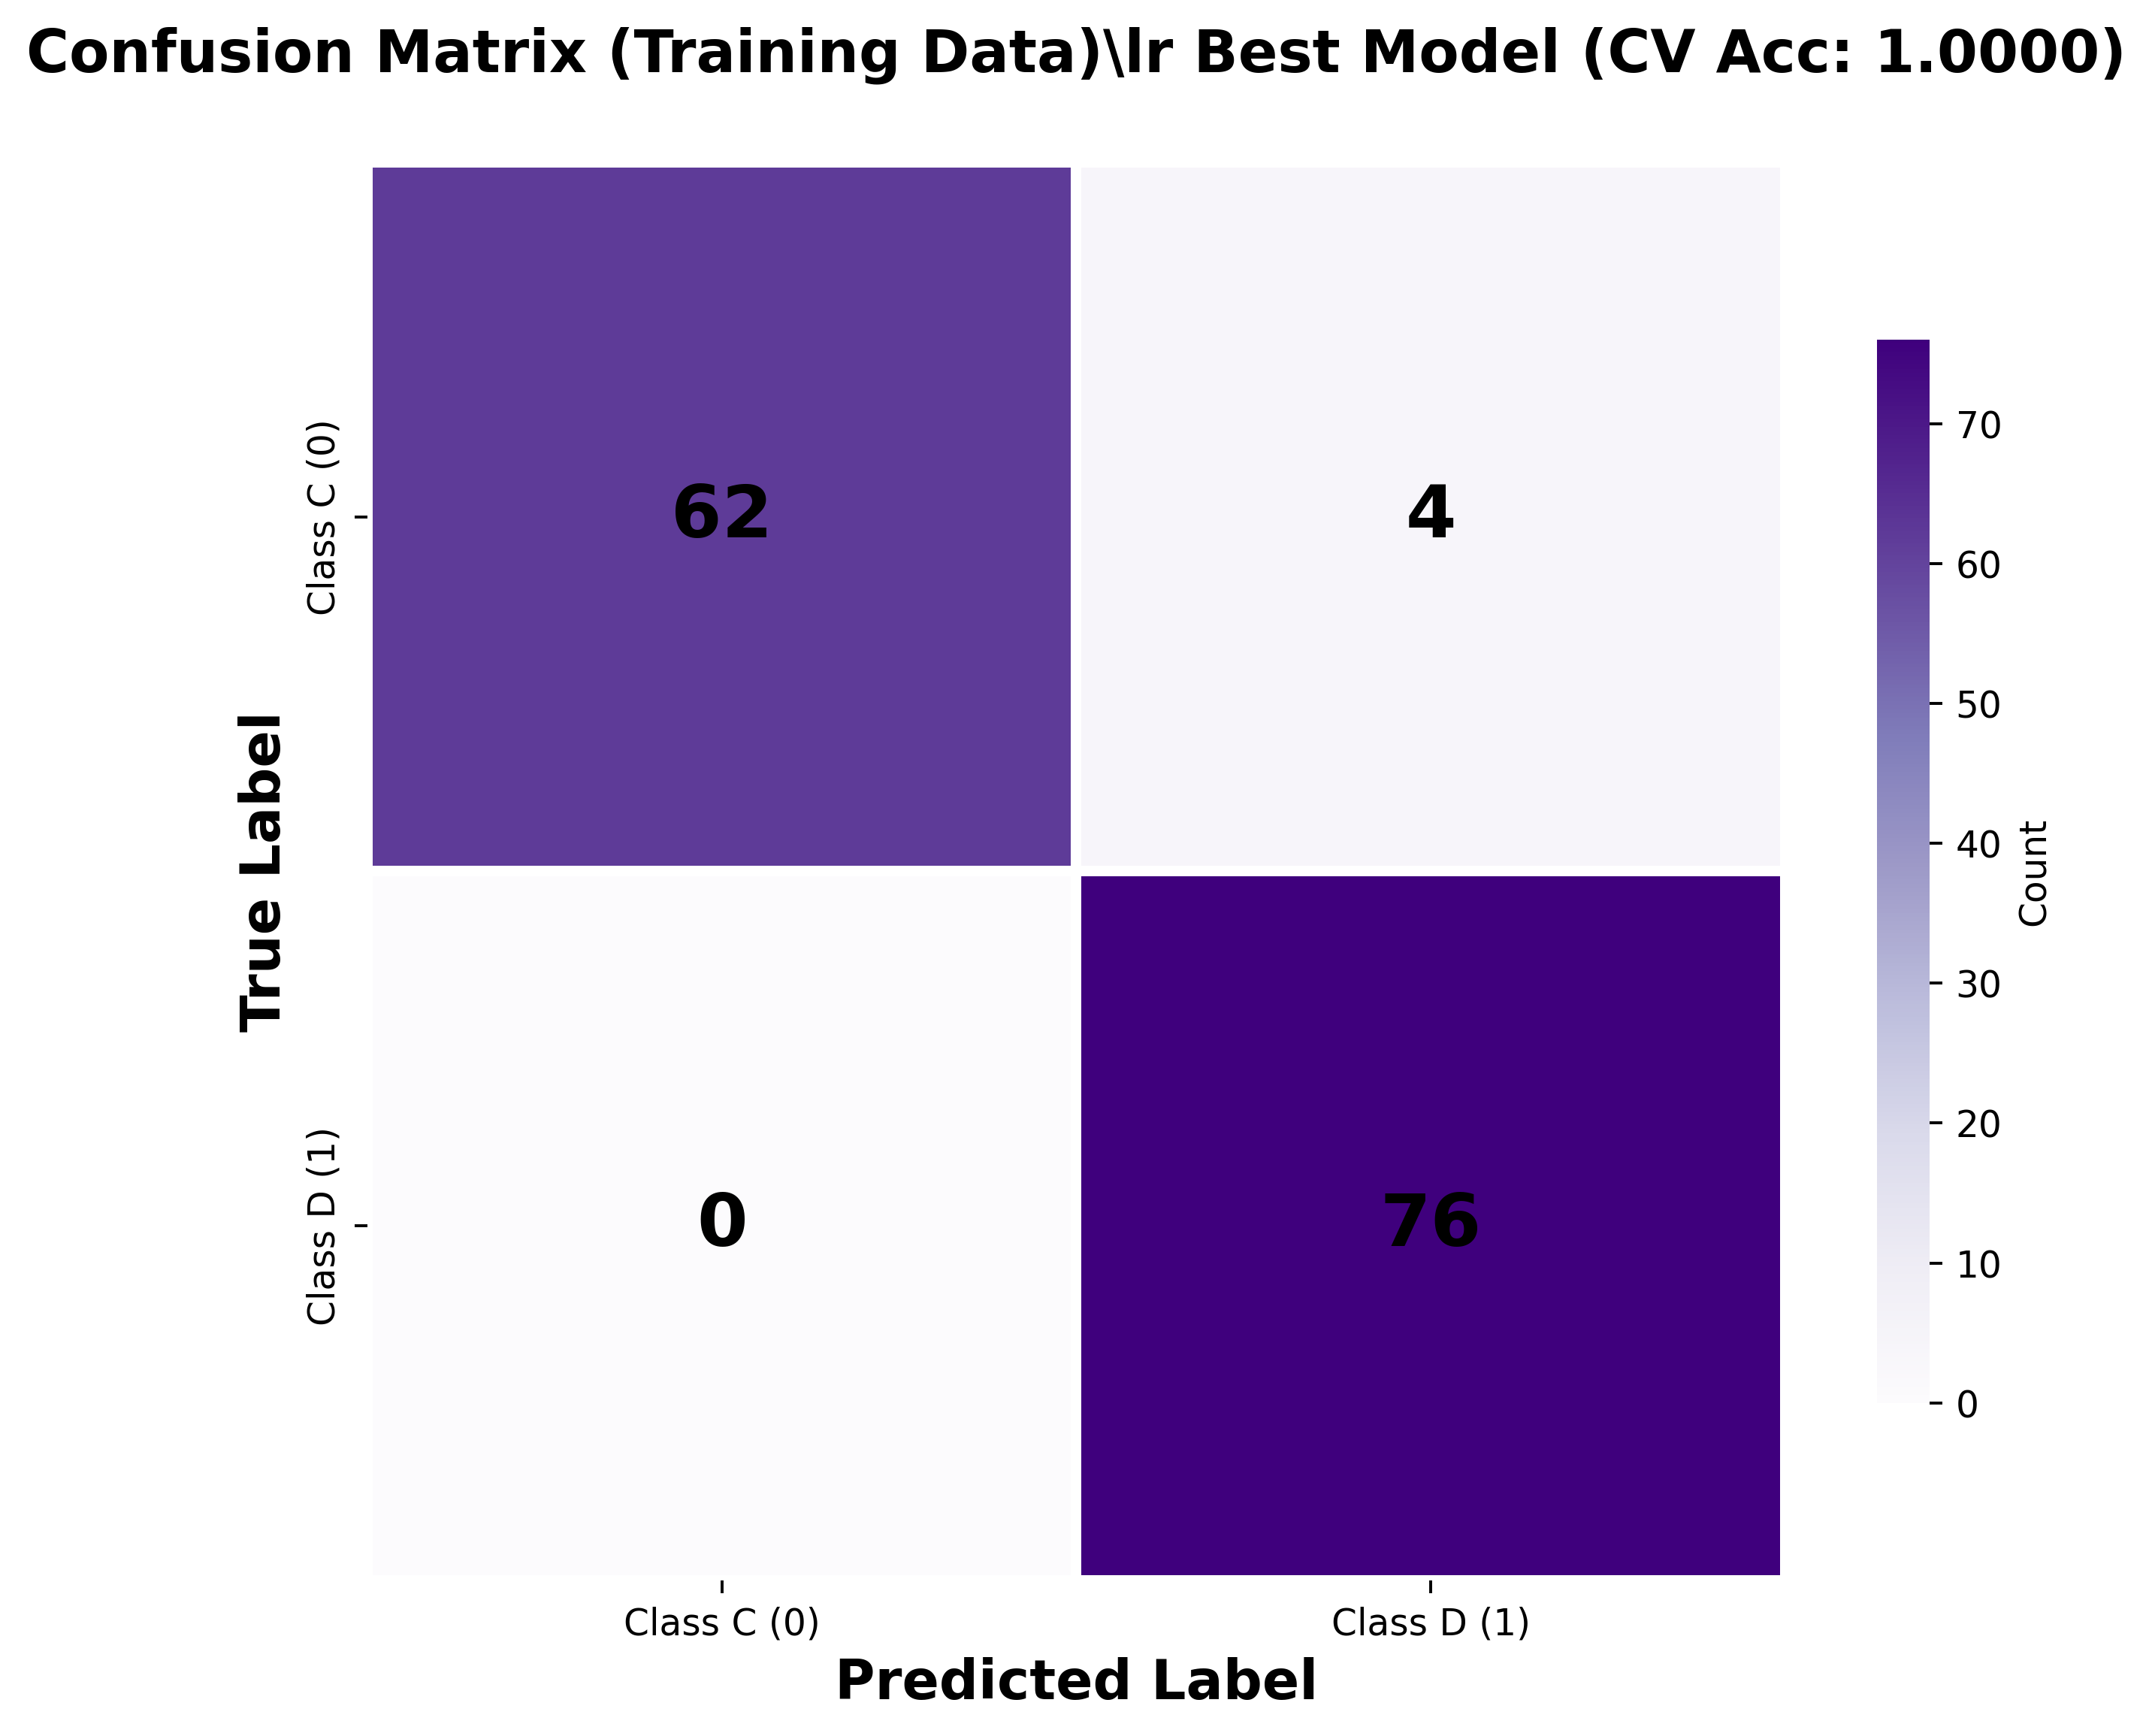


CLASSIFICATION REPORT (Overall)
              precision    recall  f1-score   support

 Class 0 (C)       1.00      0.94      0.97        66
 Class 1 (D)       0.95      1.00      0.97        76

    accuracy                           0.97       142
   macro avg       0.97      0.97      0.97       142
weighted avg       0.97      0.97      0.97       142


Files saved:
1. logreg_fixed_C0001_fold_results.csv
2. logistic_regression_C0001_maxiter100.pkl (final model fitted on full data)


In [ ]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    classification_report
)

# ============================================================
# DATA LOADING (Same as before)
# ============================================================
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data = data.T

y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y = y.reset_index(drop=True)

data.reset_index(inplace=True)
data.drop("index", axis=1, inplace=True)

X = data
X.columns = X.iloc[0]
X = X.drop(X.index[0])
X = X.apply(pd.to_numeric)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y value counts:\n{y.value_counts()}")

# ============================================================
# CROSS-VALIDATION SETUP
# ============================================================
cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=2,
    random_state=42
)

# Fixed parameters as requested
C_VALUE = 0.0001
MAX_ITER = 100

model = LogisticRegression(
    random_state=42,
    penalty='l2',
    solver='liblinear',
    C=C_VALUE,
    max_iter=MAX_ITER
)

# ============================================================
# CROSS-VALIDATION + METRICS + CONFUSION MATRIX
# ============================================================
fold_results = []
all_y_true = []
all_y_pred = []
all_y_prob = []

print("\n" + "="*60)
print(f"Training Logistic Regression with C={C_VALUE}, max_iter={MAX_ITER}")
print(f"Using RepeatedStratifiedKFold (10 splits × 2 repeats = 20 folds)")
print("="*60)

for fold_count, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Store for overall confusion matrix
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)

    # Fold metrics
    fold_results.append({
        'fold': fold_count,
        'repeat': (fold_count - 1) // 10 + 1,
        'fold_in_repeat': (fold_count - 1) % 10 + 1,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'mcc': matthews_corrcoef(y_test, y_pred),
    })

# Convert to DataFrame
fold_df = pd.DataFrame(fold_results)

# ============================================================
# OVERALL RESULTS
# ============================================================
overall_cm = confusion_matrix(all_y_true, all_y_pred)

print("\n" + "="*60)
print("OVERALL CROSS-VALIDATION RESULTS (Aggregated across 20 folds)")
print("="*60)

print(f"\nMean ± Std across 20 folds:")
print(f"Accuracy   : {fold_df['accuracy'].mean():.4f} ± {fold_df['accuracy'].std():.4f}")
print(f"Precision  : {fold_df['precision'].mean():.4f} ± {fold_df['precision'].std():.4f}")
print(f"Recall     : {fold_df['recall'].mean():.4f} ± {fold_df['recall'].std():.4f}")
print(f"F1 Score   : {fold_df['f1'].mean():.4f} ± {fold_df['f1'].std():.4f}")
print(f"ROC AUC    : {fold_df['roc_auc'].mean():.4f} ± {fold_df['roc_auc'].std():.4f}")
print(f"MCC        : {fold_df['mcc'].mean():.4f} ± {fold_df['mcc'].std():.4f}")

print("\n" + "="*60)
print("OVERALL CONFUSION MATRIX (Aggregated)")
print("="*60)
print(overall_cm)

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(9, 7), dpi=350)

sns.heatmap(
    overall_cm,
    annot=True,
    fmt='d',
    cmap="Purples",
    cbar=True,
    cbar_kws={'label': 'Count', 'shrink': 0.75},
    square=True,
    linewidths=2.5,
    linecolor='white',
    annot_kws={'size': 20, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

plt.xlabel('Predicted Label', fontsize=15, fontweight='bold')
plt.ylabel('True Label', fontsize=15, fontweight='bold')
plt.title(
    f'Confusion Matrix (Training Data)\lr Best Model (CV Acc: {grid_search.best_score_:.4f})',
    fontsize=16,
    fontweight='bold',
    pad=25
)




plt.show()

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT (Overall)")
print("="*60)
print(classification_report(all_y_true, all_y_pred, target_names=['Class 0 (C)', 'Class 1 (D)']))

# ============================================================
# SAVE RESULTS
# ============================================================
fold_df.to_csv('/content/drive/MyDrive/LR/logreg_fixed_C0001_fold_results.csv', index=False)
with open("/content/drive/MyDrive/LR/logistic_regression_C0001_maxiter100.pkl", "wb") as f:
    pickle.dump(model, f)

print("\nFiles saved:")
print("1. logreg_fixed_C0001_fold_results.csv")
print("2. logistic_regression_C0001_maxiter100.pkl (final model fitted on full data)")


Calculating SHAP values (this may take a moment)...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


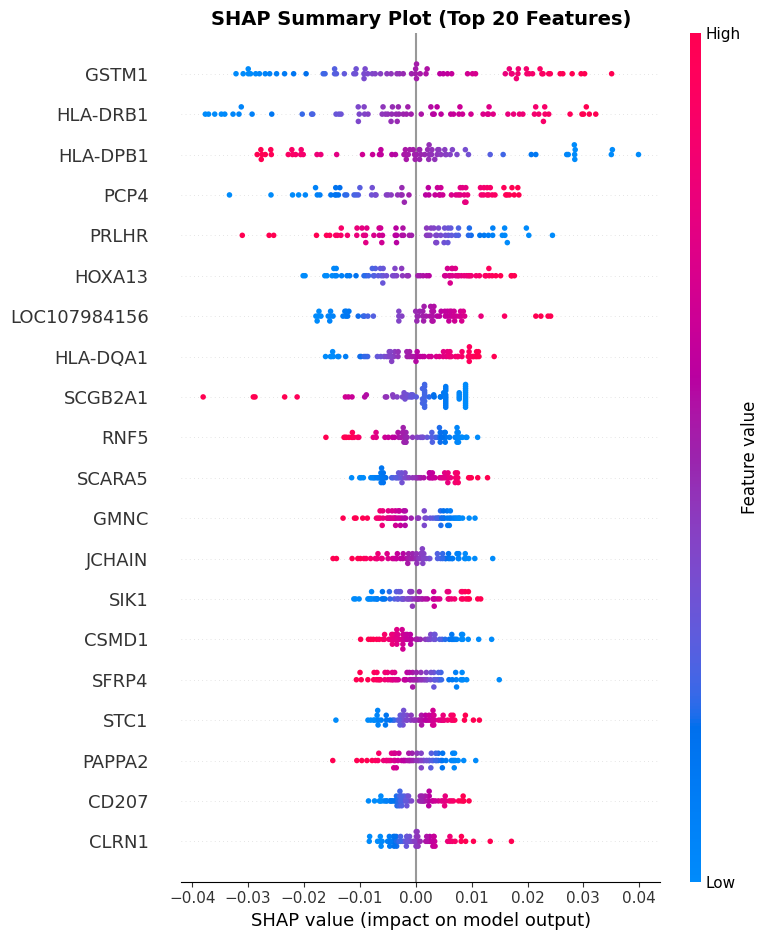

✅ SHAP summary plot saved as 'shap_summary_20260528_154614.png'


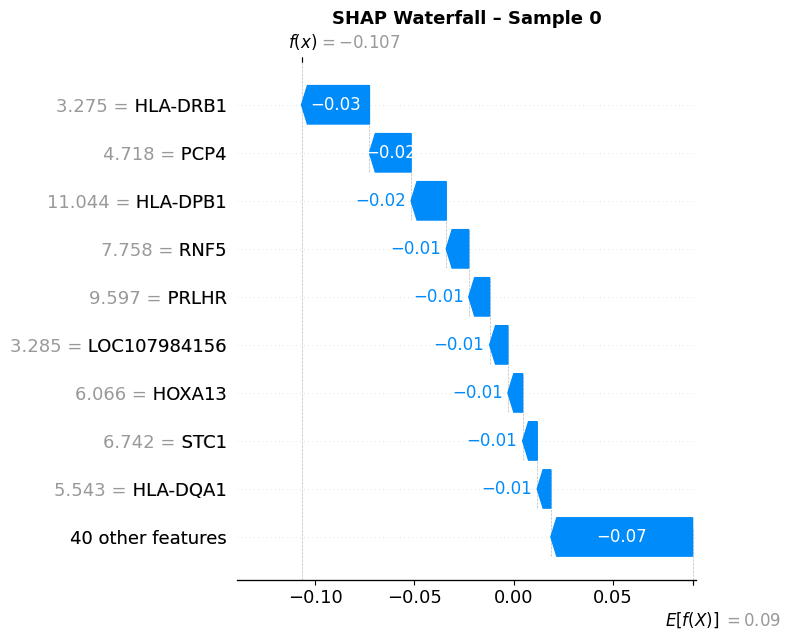

✅ SHAP waterfall saved as 'shap_waterfall_20260528_154614.png'
✅ SHAP importance saved as 'shap_importance_20260528_154614.csv'

Top 10 SHAP Features:
     Feature  Mean_Abs_SHAP
       GSTM1         0.0155
    HLA-DRB1         0.0152
    HLA-DPB1         0.0125
        PCP4         0.0109
       PRLHR         0.0092
      HOXA13         0.0088
LOC107984156         0.0083
    HLA-DQA1         0.0067
     SCGB2A1         0.0066
        RNF5         0.0057


In [ ]:
# ==========================
# 9. SHAP VALUES
# ==========================
import shap
import numpy as np
from datetime import datetime

print("\nCalculating SHAP values (this may take a moment)...")

timestamp     = datetime.now().strftime("%Y%m%d_%H%M%S")
X_array       = X.values.astype(np.float32)
feature_names = list(X.columns)

# ── LinearExplainer is correct for LogisticRegression ──────────────────────
# Fit final model on full data so the explainer has a stable background
model.fit(X, y)

explainer   = shap.LinearExplainer(model, X_array, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_array)

# LinearExplainer returns a single 2-D array (n_samples × n_features) for
# binary problems, unlike TreeExplainer which may return a list of two arrays.
# Normalise to always have a plain 2-D array for class-1 (Disease).
if isinstance(shap_values, list):
    sv = shap_values[1]          # take class-1 slice if list form
else:
    sv = shap_values             # already (n_samples × n_features)

# --- 9a. SHAP Summary Plot (Beeswarm) ---
plt.figure()
shap.summary_plot(
    sv, X_array,
    feature_names=feature_names,
    show=False, max_display=20
)
plt.title('SHAP Summary Plot (Top 20 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_summary_{timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ SHAP summary plot saved as 'shap_summary_{timestamp}.png'")

# --- 9c. SHAP Waterfall (first sample) ---
# expected_value is a scalar for LinearExplainer on binary problems
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = float(base_val[1])   # class-1 base value
else:
    base_val = float(base_val)

shap_exp = shap.Explanation(
    values        = sv[0],           # 1-D vector for sample 0
    base_values   = base_val,
    data          = X_array[0],
    feature_names = feature_names
)
plt.figure()
shap.waterfall_plot(shap_exp, show=False)
plt.title('SHAP Waterfall – Sample 0', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_waterfall_{timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ SHAP waterfall saved as 'shap_waterfall_{timestamp}.png'")

# --- 9d. SHAP Feature Importance CSV ---
mean_shap_df = pd.DataFrame({
    'Feature'       : feature_names,
    'Mean_Abs_SHAP' : np.abs(sv).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

mean_shap_df.to_csv(f'shap_importance_{timestamp}.csv', index=False)
print(f"✅ SHAP importance saved as 'shap_importance_{timestamp}.csv'")
print("\nTop 10 SHAP Features:")
print(mean_shap_df.head(10).to_string(index=False))

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('/content/validation_count_matrix.csv')
data.head()

,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,A1BG,115,85,98,70,146,97,97,29,58,...,88,193,153,125,108,402,249,57,183,132
1,A1BG-AS1,74,41,44,42,70,56,91,35,19,...,37,144,64,63,63,157,101,46,118,107
2,A1CF,0,3,1,8,1,0,6,0,0,...,11,1,1,13,4,0,3,3,5,1
3,A2M,35564,54680,33271,11252,44088,43126,31970,26536,12054,...,24199,30403,17418,18652,55256,37656,28001,11887,32520,25056
4,A2M-AS1,109,112,167,111,135,108,66,92,32,...,164,98,113,107,70,90,49,43,111,47


In [ ]:
# ==========================
# 2. LOAD LASSO GENES
# ==========================
lasso_genes = pd.read_csv('/content/LASSO_GENES.txt')
print(f"Loaded {len(lasso_genes)} LASSO genes")

# ==========================
# 3. SELECT ONLY THESE 49 GENES FROM X_val
# ==========================


merged = pd.merge(data, lasso_genes, on="Gene", how="inner")
merged

Loaded 49 LASSO genes


,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,ACSM1,339,482,225,44,62,185,124,131,34,...,109,133,53,89,311,110,104,73,41,217
1,ADORA2B,49,22,20,62,18,37,20,34,3,...,71,31,25,33,37,38,34,3,14,7
2,AGPAT1,94,4,85,31,9,102,1,79,3,...,42,139,51,1,32,183,58,25,7,129
3,BTBD16,48,18,106,40,50,79,3,63,32,...,221,30,124,197,22,19,46,16,1,15
4,CCDC178,7,5,15,24,8,7,22,4,0,...,21,5,11,15,6,9,7,13,2,3
5,CD207,12,112,25,98,222,106,55,98,40,...,14,41,11,7,8,67,21,61,25,87
6,CLRN1,168,16,13,47,20,34,9,31,6,...,21,29,8,300,5,42,19,54,2,7
7,CMA1,1,36,5,6,25,25,7,8,59,...,1,5,3,3,6,3,2,1,2,11
8,CSMD1,27,112,360,187,43,18,111,49,5,...,246,31,333,361,70,2,43,73,56,27
9,DDT,1,2,0,1,20,1,6,0,0,...,0,5,9,1,0,0,6,3,0,1


In [ ]:
data = merged.T

In [ ]:
y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y_val = y
data.reset_index(inplace = True)

data.drop("index", axis = 1, inplace = True)
X = data
# Make first row the header
X.columns = X.iloc[0]

# Remove that first row
X = X.drop(X.index[0])

# Convert to numeric
X = X.apply(pd.to_numeric)
X_val= X


In [ ]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime

# ==========================
# 1. LOAD MODEL
# ==========================
model = joblib.load('/content/drive/MyDrive/LR/logistic_regression_C0001_maxiter100.pkl')
best_model = joblib.load('/content/drive/MyDrive/LR/logistic_regression_C0001_maxiter100.pkl')

# ==========================
# 2. PREPARE VALIDATION DATA (Using all columns - as per your current code)
# ==========================
# Convert to numpy (required for XGBoost)
X_val_array = X_val.values.astype(np.float32)

print(f"Using validation data shape: {X_val_array.shape}")

# ==========================
# 3. PREDICTIONS
# ==========================
y_pred = best_model.predict(X_val_array)
y_pred_proba = best_model.predict_proba(X_val_array)[:, 1]

# ==========================
# 4. CALCULATE ALL METRICS + AUCPRC
# ==========================
metrics = {
    'Accuracy': accuracy_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba),
    'AUCPRC': average_precision_score(y_val, y_pred_proba),   # ← Added AUCPRC
    'Avg Precision': average_precision_score(y_val, y_pred_proba),
    'F1 Score': f1_score(y_val, y_pred),
    'F1 Macro': f1_score(y_val, y_pred, average='macro'),
    'F1 Weighted': f1_score(y_val, y_pred, average='weighted'),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall': recall_score(y_val, y_pred, zero_division=0),
    'MCC': matthews_corrcoef(y_val, y_pred),
}

print("\n" + "="*75)
print("📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)")
print("="*75)

for k, v in metrics.items():
    print(f"{k:20} : {v:.4f}")

print("\n" + "="*75)
print("CLASSIFICATION REPORT")
print("="*75)
print(classification_report(y_val, y_pred, digits=4))

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
pd.DataFrame([metrics]).to_csv(f'validation_metrics_{timestamp}.csv', index=False)
print(f"\n✅ Metrics saved as 'validation_metrics_{timestamp}.csv'")

Using validation data shape: (35, 49)

📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)
Accuracy             : 0.5429
ROC-AUC              : 0.5700
AUCPRC               : 0.7091
Avg Precision        : 0.7091
F1 Score             : 0.5556
F1 Macro             : 0.5425
F1 Weighted          : 0.5444
Precision            : 0.6250
Recall               : 0.5000
MCC                  : 0.0993

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0     0.4737    0.6000    0.5294        15
         1.0     0.6250    0.5000    0.5556        20

    accuracy                         0.5429        35
   macro avg     0.5493    0.5500    0.5425        35
weighted avg     0.5602    0.5429    0.5444        35


✅ Metrics saved as 'validation_metrics_20260624_1423.csv'


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


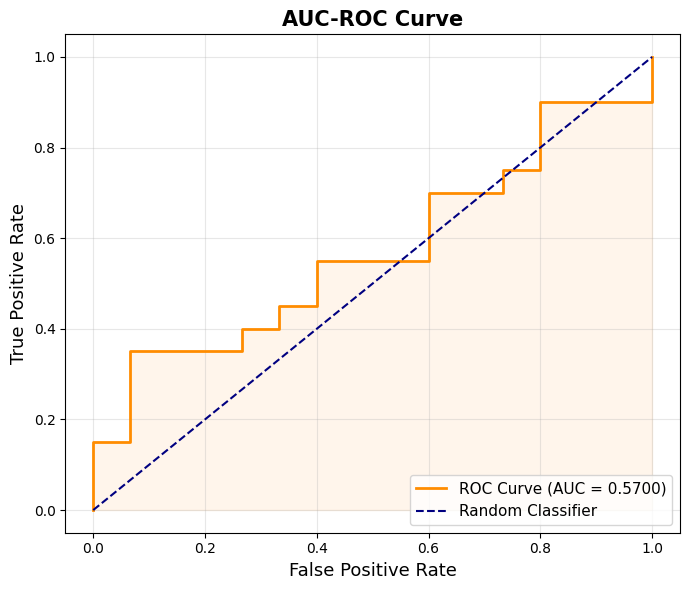

✅ AUC-ROC curve saved as 'aucroc_curve.png'


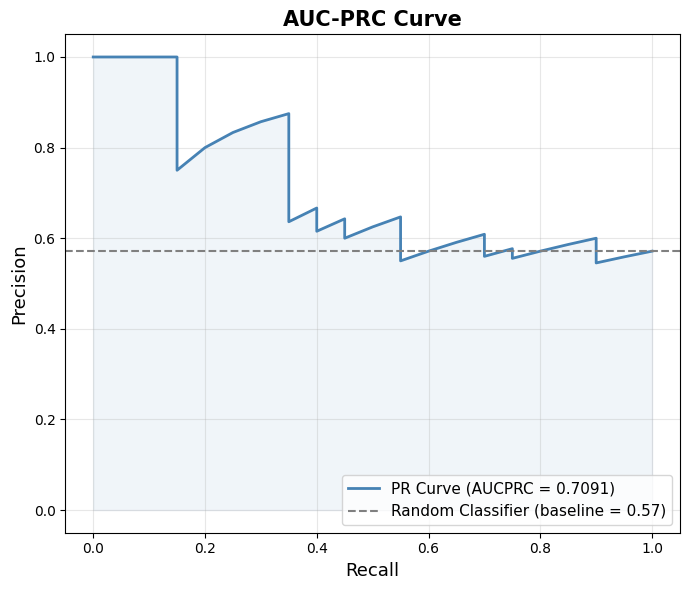

✅ AUC-PRC curve saved as 'aucprc_curve.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)

# ==========================
# 5. AUC-ROC CURVE
# ==========================
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
roc_auc     = metrics['ROC-AUC']

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.08, color='darkorange')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('AUC-ROC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aucroc_curve.png', dpi=150)
plt.show()
print("✅ AUC-ROC curve saved as 'aucroc_curve.png'")

# ==========================
# 6. AUC-PRC CURVE
# ==========================
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_pred_proba)
aucprc   = metrics['AUCPRC']
baseline = np.sum(y_val) / len(y_val)

plt.figure(figsize=(7, 6))
plt.plot(recall_vals, precision_vals, color='steelblue', lw=2,
         label=f'PR Curve (AUCPRC = {aucprc:.4f})')
plt.axhline(y=baseline, color='gray', lw=1.5, linestyle='--',
            label=f'Random Classifier (baseline = {baseline:.2f})')
plt.fill_between(recall_vals, precision_vals, alpha=0.08, color='steelblue')
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('AUC-PRC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aucprc_curve.png', dpi=150)
plt.show()
print("✅ AUC-PRC curve saved as 'aucprc_curve.png'")



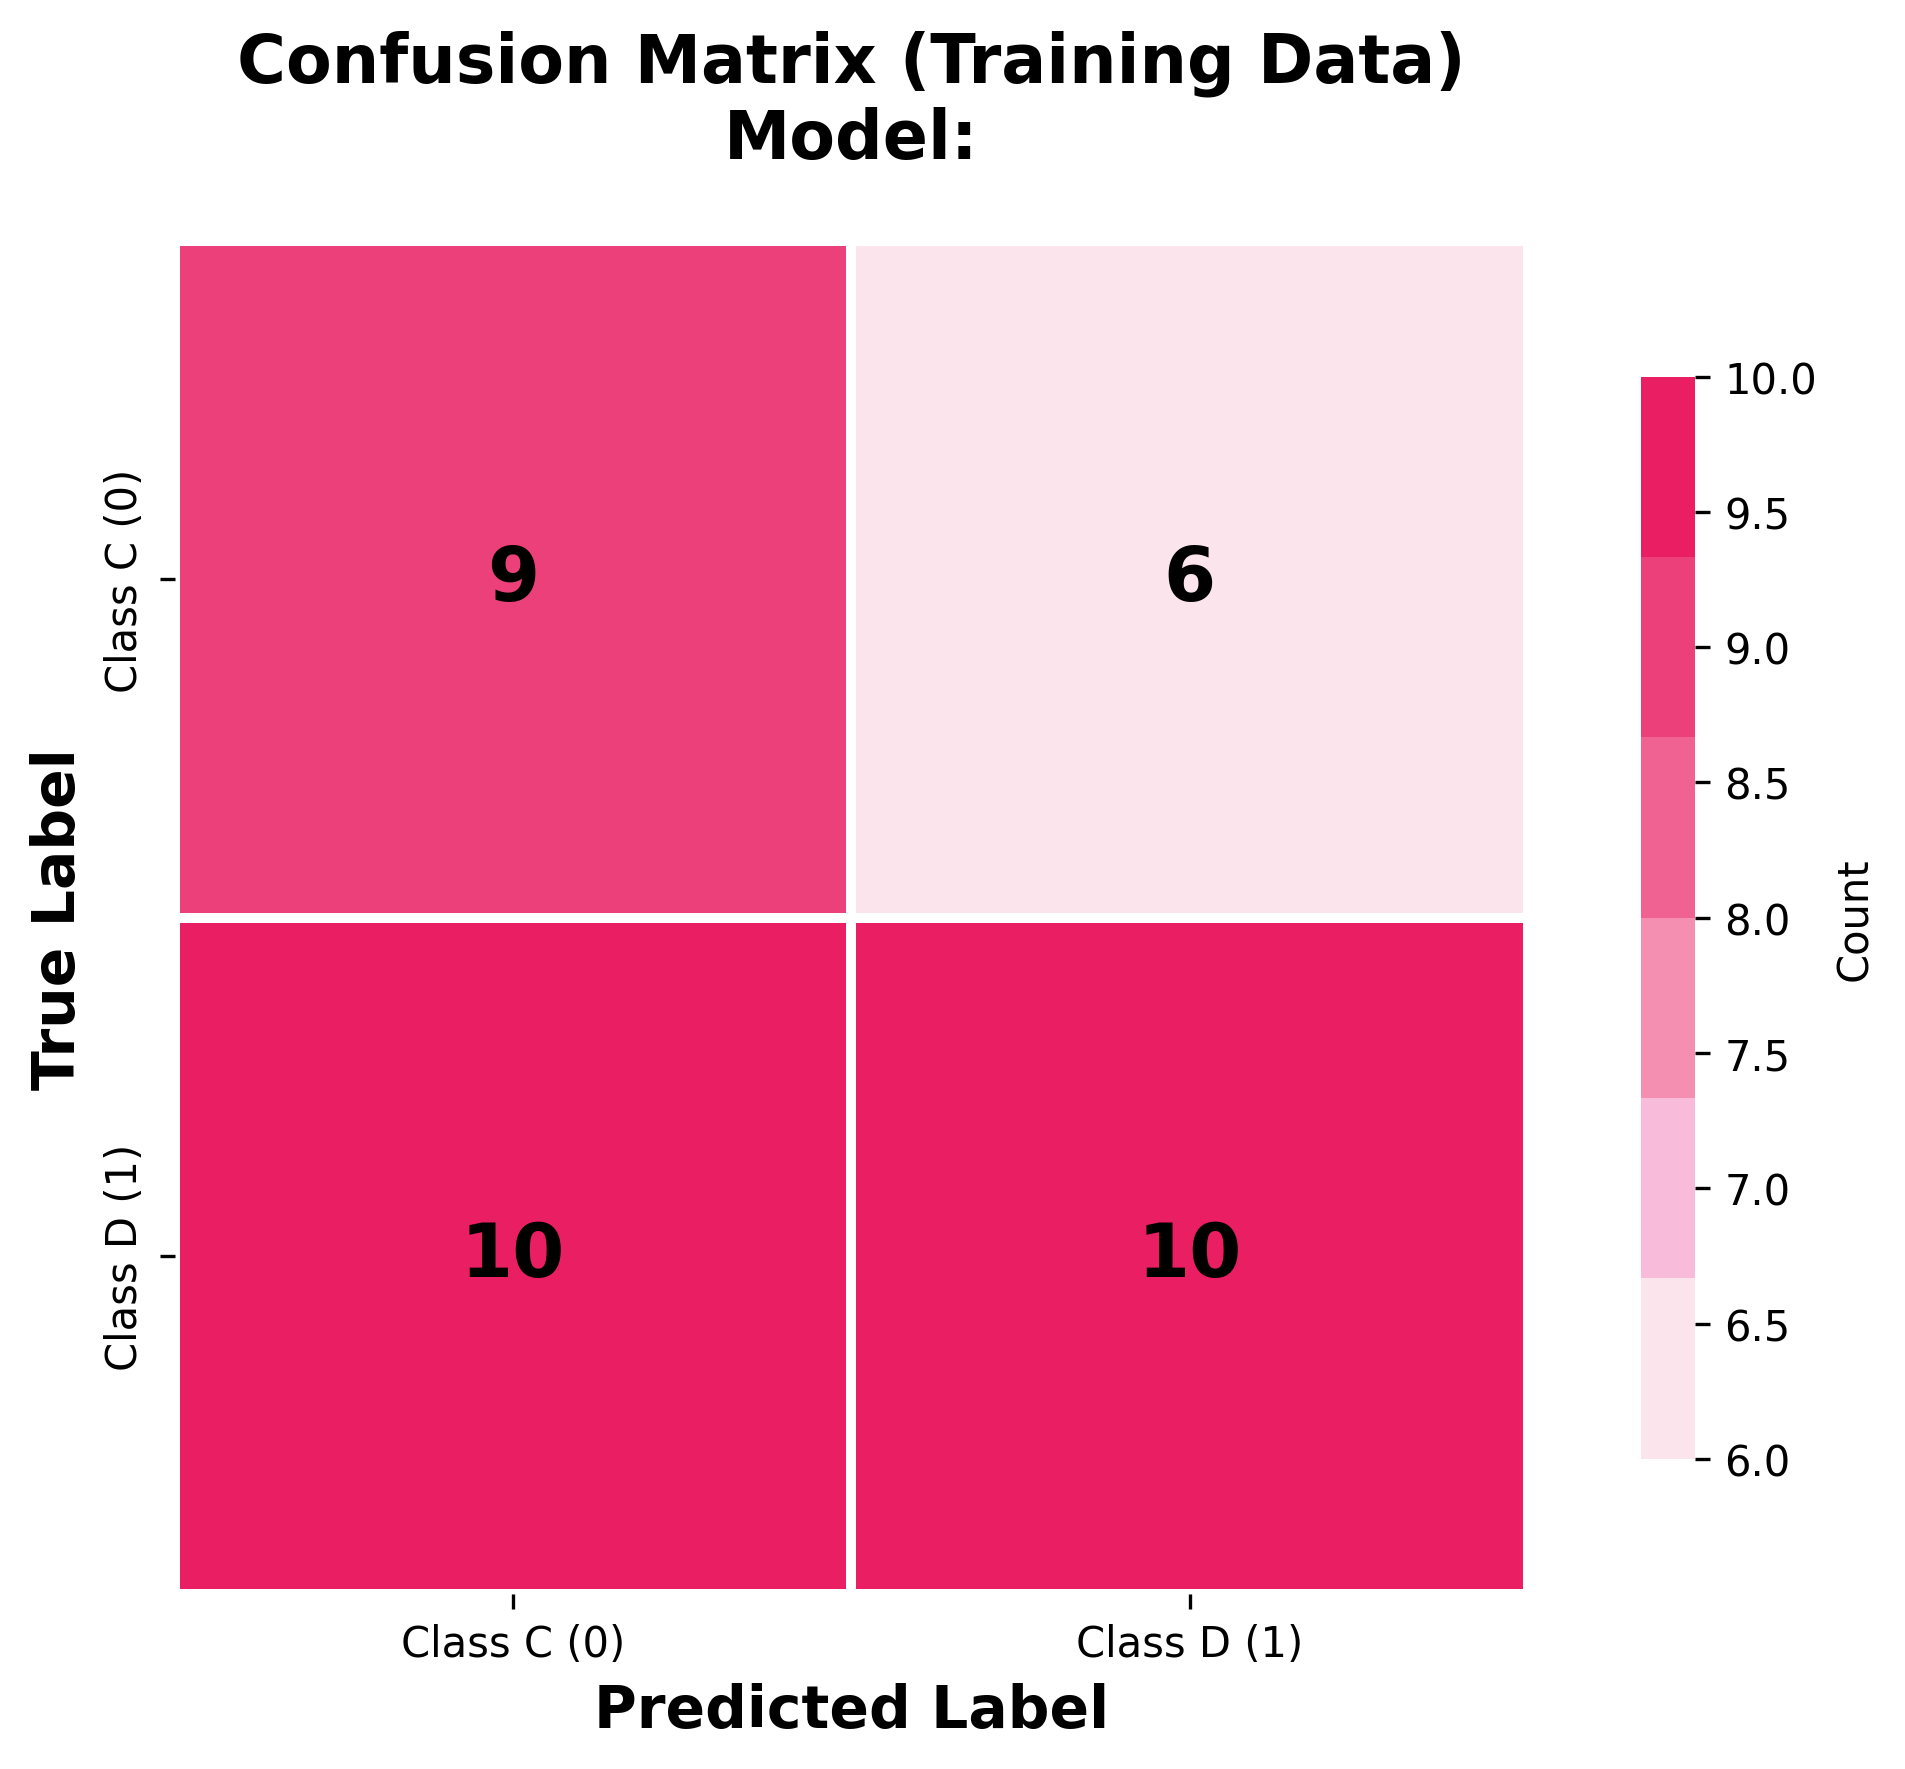


✅ Confusion matrix saved as 'confusion_matrix_20260624_142345.png'

MODEL PERFORMANCE METRICS
Accuracy:  0.5429
Precision: 0.6250
Recall:    0.5000
F1-Score:  0.5556
MCC:       0.0993

CONFUSION MATRIX (Raw Counts)
                    Predicted C    Predicted D
True Class C                 9             6
True Class D                10            10


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef
)
from matplotlib.colors import ListedColormap

# ============================================================
# MAKE PREDICTIONS
# ============================================================
# y_pred = model.predict(X_val)

# ============================================================
# COMPUTE CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_val, y_pred)

# ============================================================
# PLOT PINK CONFUSION MATRIX
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Sweet pink colormap
pink_colors = ['#fce4ec', '#f8bbd9', '#f48fb1', '#f06292', '#ec407a', '#e91e63']
pink_cmap = ListedColormap(pink_colors)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=pink_cmap,
    cbar=True,
    cbar_kws={'label': 'Count', 'shrink': 0.8},
    square=True,
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 18, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

# Title with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.title(
    f'Confusion Matrix (Training Data)\nModel:',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.savefig(
    f'confusion_matrix_{timestamp}.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

print(f"\n✅ Confusion matrix saved as 'confusion_matrix_{timestamp}.png'")

# ============================================================
# PRINT METRICS
# ============================================================
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)
mcc = matthews_corrcoef(y_val, y_pred)

print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")

print("\n" + "="*60)
print("CONFUSION MATRIX (Raw Counts)")
print("="*60)
print(f"                    Predicted C    Predicted D")
print(f"True Class C        {cm[0,0]:>10d}    {cm[0,1]:>10d}")
print(f"True Class D        {cm[1,0]:>10d}    {cm[1,1]:>10d}")